# Taller -- Explicabilidad, Sesgo y Etica en ML
## XAI aplicada a la Prediccion de Churn en Telecomunicaciones
### Dataset: Telco Customer Churn

**Curso:** Aprendizaje Automatico  
**Grupo:** 9  
**Integrantes:** 
- Henry Eduardo Medina Castillo  
- Anthony William Madezco Posada
- William Antonio Andrade Casanova

**Repositorio:** [URL GitHub/GitLab]

---

## Contexto y justificacion del dataset

Se utiliza el dataset **Telco Customer Churn** (IBM Watson Analytics), previamente trabajado en las Actividades 1 y 2, por las siguientes razones:

| Criterio | Justificacion |
|----------|--------------|
| **Continuidad del proyecto** | Permite comparar resultados con modelos anteriores |
| **Relevancia etica** | Contiene variables sensibles: `gender`, `SeniorCitizen`, `Partner` |
| **Aplicacion real** | Las decisiones automaticas de retencion afectan directamente a personas |
| **Compatibilidad XAI** | SHAP y LIME funcionan optimamente con datos tabulares estructurados |


---

## 1. Preparacion del Entorno

### 1.1 Instalacion de librerias XAI

In [24]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    import shap
    print(f"shap {shap.__version__} ya instalado")
except ImportError:
    print("Instalando shap...")
    install("shap")
    import shap
    print(f"shap {shap.__version__} instalado")

try:
    import lime
    print("lime ya instalado")
except ImportError:
    print("Instalando lime...")
    install("lime")
    import lime
    print("lime instalado")


shap 0.51.0 ya instalado
lime ya instalado


In [25]:
import sys, sklearn, pandas as pd, numpy as np
import matplotlib, seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import shap
import lime
import lime.lime_tabular

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


---
## 2. Carga y Preprocesamiento

Se replica el pipeline de preprocesamiento de la Actividad 2 para garantizar reproducibilidad y comparabilidad de resultados.

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df_raw = pd.read_csv("Telco-Customer-Churn.csv")
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")

df = df_raw.copy()
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Guardar variables sensibles ANTES de codificar (para analisis de sesgo)
gender_raw   = df["gender"].copy()
senior_raw   = df["SeniorCitizen"].copy()

binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df_encoded = pd.get_dummies(df, drop_first=True)

y = df_encoded["Churn"]
X = df_encoded.drop("Churn", axis=1)
feature_names = list(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.20, random_state=42, stratify=y)

idx_test = y_test.index
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Churn Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")
print(f"Variables: {len(feature_names)}")


Dataset cargado: 7,043 filas x 21 columnas
Train: (5625, 30)  |  Test: (1407, 30)
Churn Train: 26.58%  |  Test: 26.58%
Variables: 30


---
## 3. Entrenamiento del Modelo

Se selecciona **Random Forest** como modelo principal (mejor rendimiento en Actividad 2). Se incluye **Logistic Regression** como modelo complementario.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              accuracy_score, f1_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             max_features="sqrt", random_state=42,
                             class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  RANDOM FOREST -- Resultados en Test")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["No Churn","Churn"]))


  RANDOM FOREST -- Resultados en Test
  Accuracy  : 0.7491
  Recall    : 0.7941
  F1-Score  : 0.6272
  AUC-ROC   : 0.8413

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



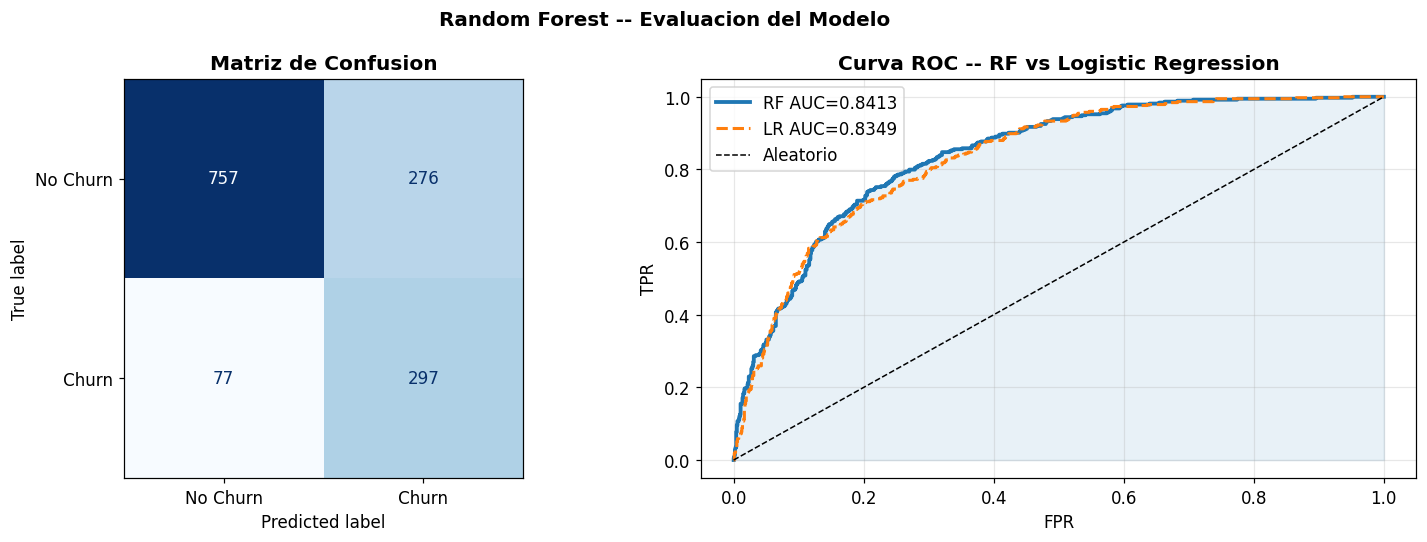

In [28]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Forest -- Evaluacion del Modelo", fontweight="bold", fontsize=13)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de Confusion", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_val = auc(fpr, tpr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

axes[1].plot(fpr, tpr, color="#1f77b4", linewidth=2.5, label=f"RF AUC={auc_val:.4f}")
axes[1].plot(fpr_lr, tpr_lr, color="#ff7f0e", linewidth=2, linestyle="--",
             label=f"LR AUC={auc_lr:.4f}")
axes[1].plot([0,1],[0,1],"k--",linewidth=1,label="Aleatorio")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC -- RF vs Logistic Regression", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 4. Explicabilidad con SHAP (Shapley Values)

### Que es SHAP?

**SHAP** (SHapley Additive exPlanations) asigna a cada variable una contribucion marginal a la prediccion, basada en la teoria de juegos cooperativos de Shapley.

Para una prediccion individual:

```
f(x) = E[f(x)] + suma_i(phi_i)
```

Donde:
- `E[f(x)]` = prediccion base (valor medio del modelo)
- `phi_i` = valor SHAP de la variable i (contribucion positiva o negativa)

**Propiedades clave:**
- **Consistencia:** si una variable contribuye mas, su SHAP es mayor
- **Nulidad:** variables sin efecto tienen SHAP = 0
- **Aditividad:** la suma de todos los SHAP = prediccion menos valor base

### 4.1 Calculo de valores SHAP (TreeExplainer)

In [29]:
print("Calculando valores SHAP (TreeExplainer)...")

explainer_shap = shap.TreeExplainer(rf)

np.random.seed(42)

n_shap = min(500, len(X_test))

idx_shap_sample = np.random.choice(
    len(X_test),
    n_shap,
    replace=False
)

X_shap_sample = X_test.iloc[idx_shap_sample]

# SHAP values
shap_values = explainer_shap.shap_values(X_shap_sample)

# Ver estructura
print(type(shap_values))
print(np.array(shap_values).shape)


Calculando valores SHAP (TreeExplainer)...
<class 'numpy.ndarray'>
(500, 30, 2)


In [30]:
# Compatibilidad entre versiones SHAP
if isinstance(shap_values, list):
    shap_churn = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_churn = shap_values[:, :, 1]
    else:
        shap_churn = shap_values

print("SHAP:", shap_churn.shape)
print("X:", X_shap_sample.shape)

print(f"SHAP calculado sobre {n_shap} instancias")

# Expected value seguro
if isinstance(explainer_shap.expected_value, (list, np.ndarray)):
    base_value = explainer_shap.expected_value[-1]
else:
    base_value = explainer_shap.expected_value

print(f"Valor base del modelo: {base_value}")

print(
    f"Probabilidad media en muestra: "
    f"{rf.predict_proba(X_shap_sample)[:, 1].mean():.4f}"
)

SHAP: (500, 30)
X: (500, 30)
SHAP calculado sobre 500 instancias
Valor base del modelo: 0.49950330039687935
Probabilidad media en muestra: 0.4159


### 4.2 Importancia global -- SHAP Summary Plot (Beeswarm)

Generando SHAP Summary Plot...


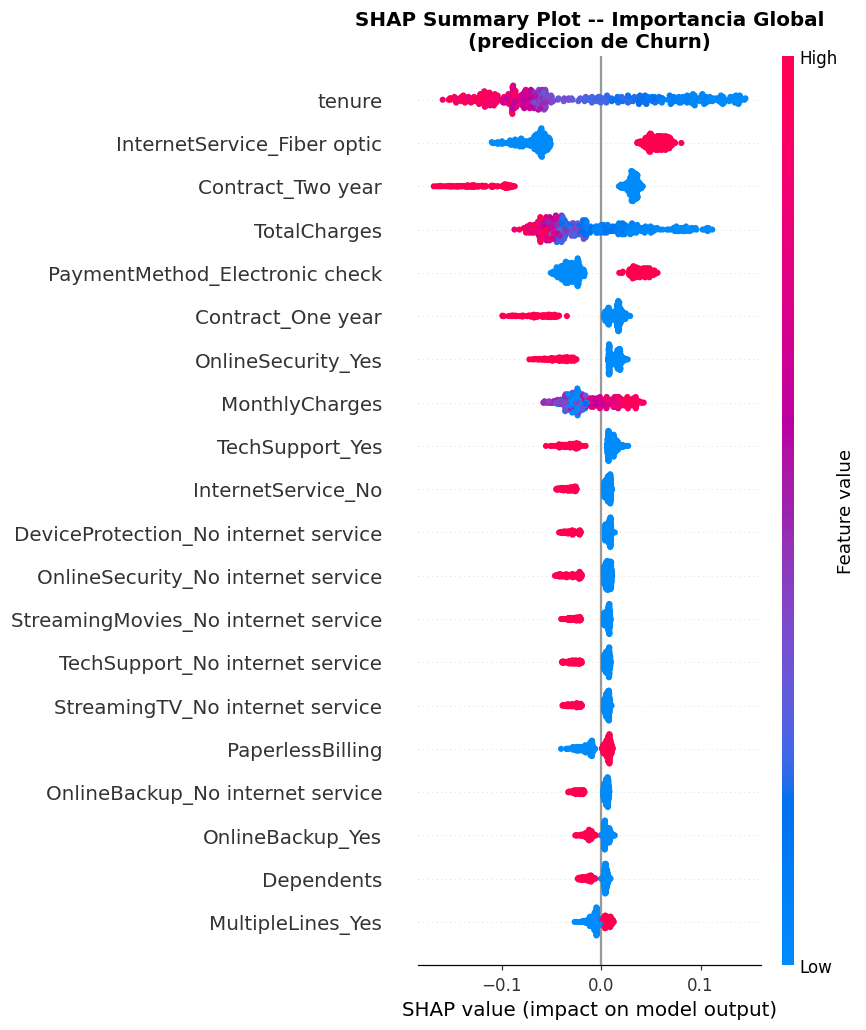

Como leer el grafico:
  Eje X: valor SHAP (positivo = aumenta P(Churn))
  Color: valor de la variable (rojo = alto, azul = bajo)
  Posicion Y: variables ordenadas de mayor a menor importancia
  Cada punto = una instancia del conjunto de test


In [31]:
print("Generando SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_churn, X_shap_sample, feature_names=feature_names,
                  plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary Plot -- Importancia Global\n(prediccion de Churn)",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("Como leer el grafico:")
print("  Eje X: valor SHAP (positivo = aumenta P(Churn))")
print("  Color: valor de la variable (rojo = alto, azul = bajo)")
print("  Posicion Y: variables ordenadas de mayor a menor importancia")
print("  Cada punto = una instancia del conjunto de test")


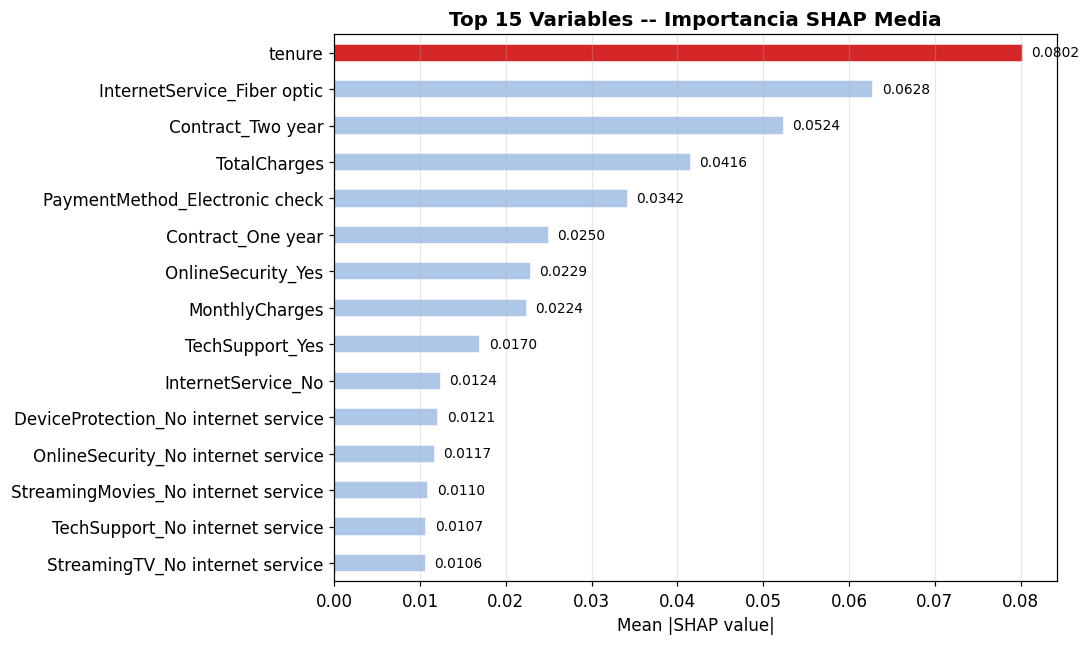

Top 5 variables mas influyentes:
  tenure                              SHAP medio = 0.08024
  InternetService_Fiber optic         SHAP medio = 0.06283
  Contract_Two year                   SHAP medio = 0.05239
  TotalCharges                        SHAP medio = 0.04156
  PaymentMethod_Electronic check      SHAP medio = 0.03418


In [32]:
mean_abs_shap = np.abs(shap_churn).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=True)
top15 = shap_importance.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if v == top15.max() else "#aec7e8" for v in top15.values]
top15.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 15 Variables -- Importancia SHAP Media", fontweight="bold", fontsize=13)
ax.set_xlabel("Mean |SHAP value|")
for i, v in enumerate(top15.values):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 variables mas influyentes:")
for var, val in shap_importance.tail(5)[::-1].items():
    print(f"  {var:<35} SHAP medio = {val:.5f}")


### 4.3 SHAP Dependence Plots -- relacion entre variable y su impacto

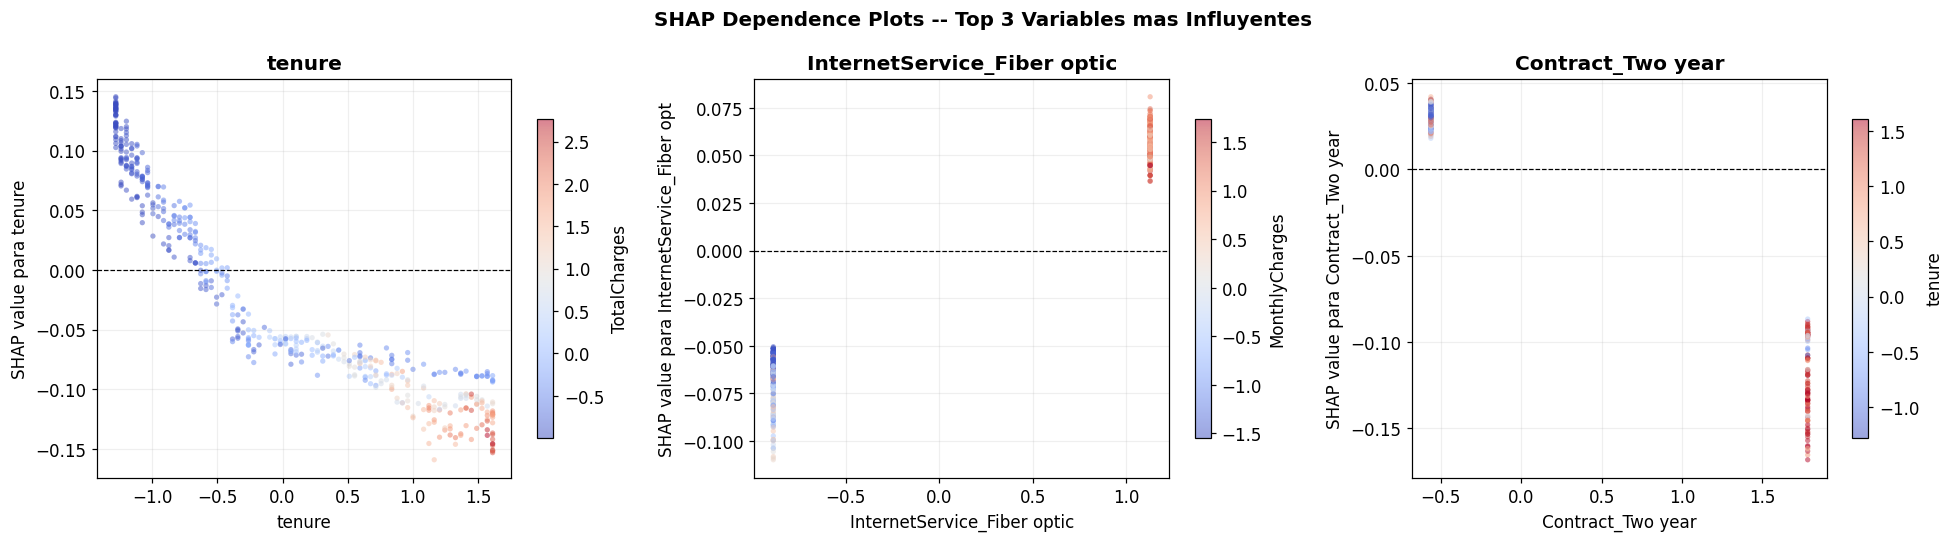

Como leer el Dependence Plot:
  Eje X: valor real de la variable
  Eje Y: contribucion SHAP (Y>0 aumenta P(Churn), Y<0 la reduce)
  Color: variable con mayor interaccion detectada


In [33]:
top3_vars = shap_importance.tail(3).index[::-1].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SHAP Dependence Plots -- Top 3 Variables mas Influyentes",
             fontweight="bold", fontsize=13)

for ax, var in zip(axes, top3_vars):
    var_idx = feature_names.index(var)
    shap_col = shap_churn[:, var_idx]
    x_col    = X_shap_sample[var].values
    corr_row = np.abs(np.corrcoef(shap_churn.T))[var_idx]
    corr_row[var_idx] = 0
    interact_idx = np.argmax(corr_row)
    interact_var = feature_names[interact_idx]
    color_col = X_shap_sample[interact_var].values
    sc = ax.scatter(x_col, shap_col, c=color_col, cmap="coolwarm",
                    alpha=0.5, s=12, edgecolors="none")
    plt.colorbar(sc, ax=ax, label=interact_var[:20], shrink=0.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(var)
    ax.set_ylabel(f"SHAP value para {var[:25]}")
    ax.set_title(f"{var[:30]}", fontweight="bold")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Como leer el Dependence Plot:")
print("  Eje X: valor real de la variable")
print("  Eje Y: contribucion SHAP (Y>0 aumenta P(Churn), Y<0 la reduce)")
print("  Color: variable con mayor interaccion detectada")


### 4.4 Explicacion local -- instancias individuales (Waterfall)

In [34]:
y_prob_shap = rf.predict_proba(X_shap_sample)[:, 1]
y_pred_shap = (y_prob_shap >= 0.5).astype(int)
y_true_shap = y_test.iloc[idx_shap_sample].values

tp_mask = (y_pred_shap == 1) & (y_true_shap == 1)
tp_idx  = np.where(tp_mask)[0]
caso_a  = tp_idx[np.argmax(y_prob_shap[tp_idx])] if len(tp_idx) > 0 else 0

tn_mask = (y_pred_shap == 0) & (y_true_shap == 0)
tn_idx  = np.where(tn_mask)[0]
caso_b  = tn_idx[np.argmin(y_prob_shap[tn_idx])] if len(tn_idx) > 0 else 1

print(f"Caso A -- Cliente en riesgo (True Positive):")
print(f"  P(Churn) = {y_prob_shap[caso_a]:.4f} | Real: Churn")
print(f"Caso B -- Cliente fiel (True Negative):")
print(f"  P(Churn) = {y_prob_shap[caso_b]:.4f} | Real: No Churn")


Caso A -- Cliente en riesgo (True Positive):
  P(Churn) = 0.9381 | Real: Churn
Caso B -- Cliente fiel (True Negative):
  P(Churn) = 0.0128 | Real: No Churn


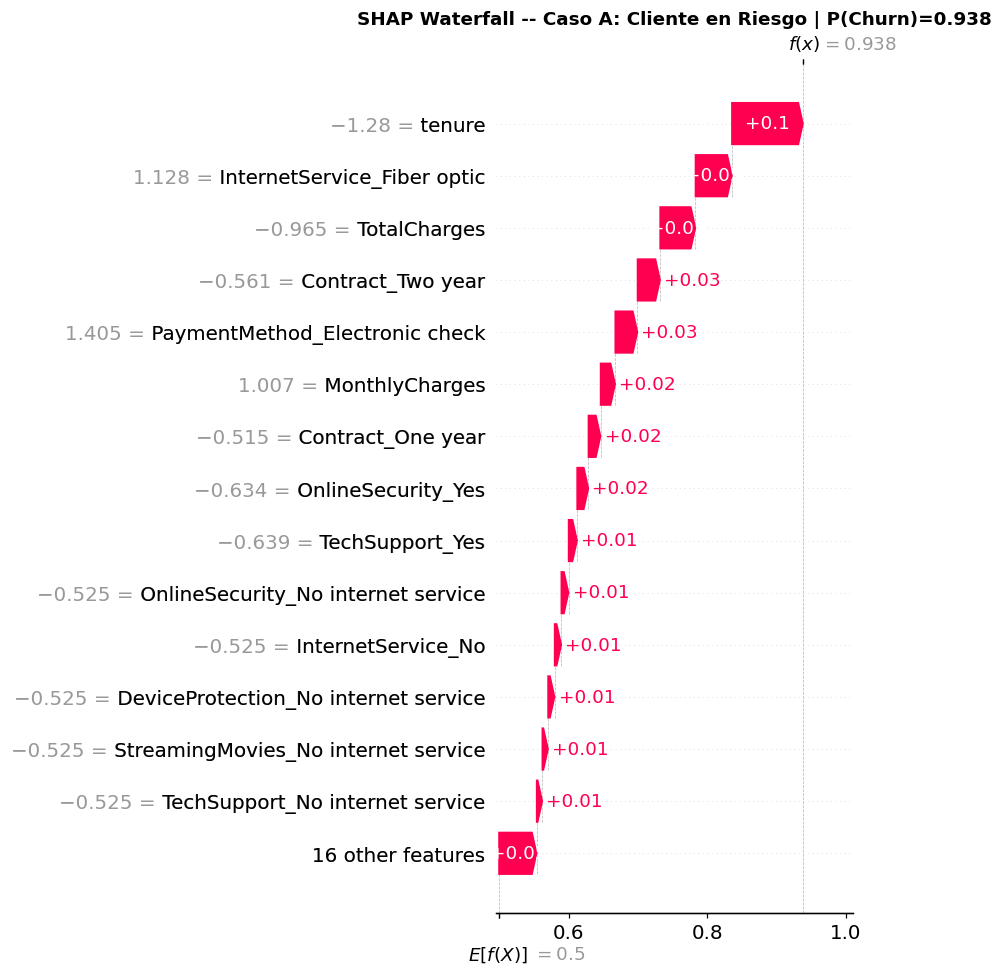

In [35]:
# Waterfall Caso A
shap_exp_a = shap.Explanation(
    values      = shap_churn[caso_a],
    base_values = explainer_shap.expected_value[1],
    data        = X_shap_sample.iloc[caso_a].values,
    feature_names = feature_names
)
plt.figure(figsize=(11, 7))
shap.waterfall_plot(shap_exp_a, max_display=15, show=False)
plt.title(f"SHAP Waterfall -- Caso A: Cliente en Riesgo | P(Churn)={y_prob_shap[caso_a]:.3f}",
          fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()


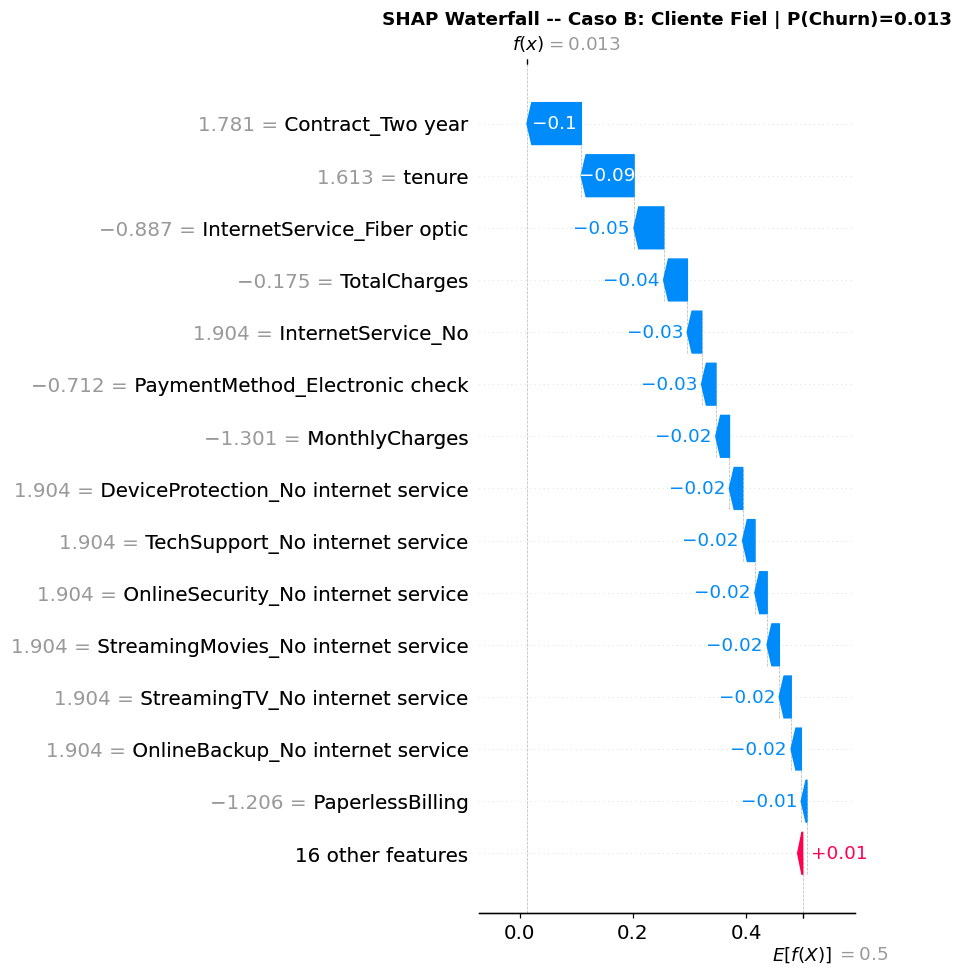

Como leer el Waterfall Plot:
  E[f(x)] = prediccion base (promedio del modelo)
  f(x)    = prediccion final para esta instancia
  Barras rojas:  variables que AUMENTAN P(Churn)
  Barras azules: variables que REDUCEN P(Churn)


In [36]:
# Waterfall Caso B
shap_exp_b = shap.Explanation(
    values      = shap_churn[caso_b],
    base_values = explainer_shap.expected_value[1],
    data        = X_shap_sample.iloc[caso_b].values,
    feature_names = feature_names
)
plt.figure(figsize=(11, 7))
shap.waterfall_plot(shap_exp_b, max_display=15, show=False)
plt.title(f"SHAP Waterfall -- Caso B: Cliente Fiel | P(Churn)={y_prob_shap[caso_b]:.3f}",
          fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

print("Como leer el Waterfall Plot:")
print("  E[f(x)] = prediccion base (promedio del modelo)")
print("  f(x)    = prediccion final para esta instancia")
print("  Barras rojas:  variables que AUMENTAN P(Churn)")
print("  Barras azules: variables que REDUCEN P(Churn)")


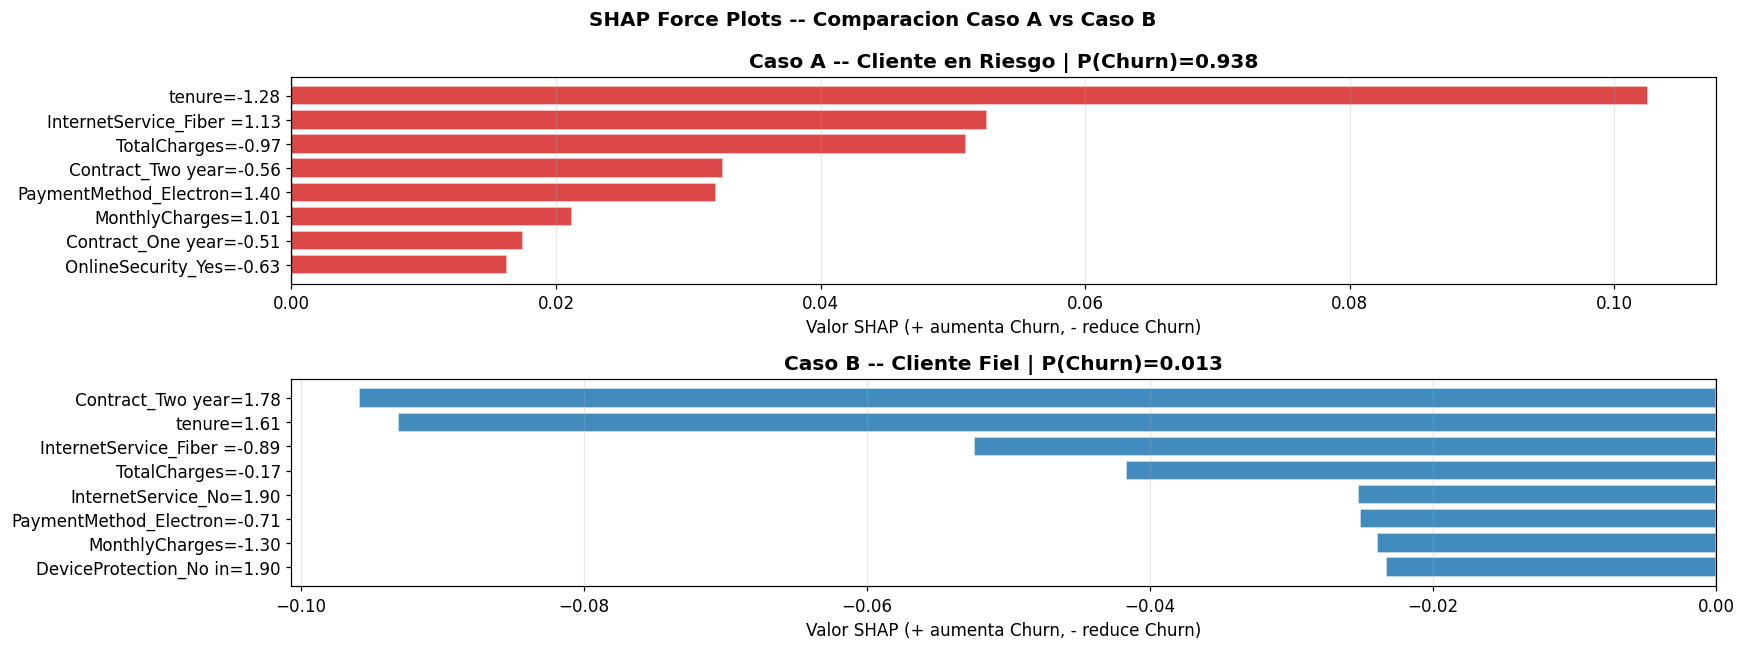

In [37]:
# Comparacion Force Plot (matplotlib)
fig, axes = plt.subplots(2, 1, figsize=(16, 6))
fig.suptitle("SHAP Force Plots -- Comparacion Caso A vs Caso B",
             fontweight="bold", fontsize=13)

for ax_idx, (caso, titulo, prob) in enumerate([
    (caso_a, "Caso A -- Cliente en Riesgo", y_prob_shap[caso_a]),
    (caso_b, "Caso B -- Cliente Fiel",      y_prob_shap[caso_b])
]):
    shap_vals = shap_churn[caso]
    feat_vals = X_shap_sample.iloc[caso].values
    top8_idx  = np.argsort(np.abs(shap_vals))[-8:]
    top8_names = [f"{feature_names[i][:22]}={feat_vals[i]:.2f}" for i in top8_idx]
    top8_shap  = shap_vals[top8_idx]
    colors_fp  = ["#d62728" if v > 0 else "#1f77b4" for v in top8_shap]
    axes[ax_idx].barh(top8_names, top8_shap, color=colors_fp, edgecolor="white", alpha=0.85)
    axes[ax_idx].axvline(0, color="black", linewidth=0.8)
    axes[ax_idx].set_title(f"{titulo} | P(Churn)={prob:.3f}", fontweight="bold")
    axes[ax_idx].set_xlabel("Valor SHAP (+ aumenta Churn, - reduce Churn)")
    axes[ax_idx].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5. Explicabilidad con LIME

### Que es LIME?

**LIME** (Local Interpretable Model-agnostic Explanations) explica predicciones individuales entrenando un modelo lineal simple en la vecindad local de cada instancia.

**Proceso:**
1. Toma la instancia a explicar
2. Genera perturbaciones aleatorias a su alrededor
3. El modelo original (RF) predice esas perturbaciones
4. Se entrena una regresion lineal ponderada por proximidad
5. Los coeficientes = explicacion de la prediccion local

**Diferencia clave con SHAP:**
- SHAP: garantias formales basadas en teoria de juegos, vision global + local
- LIME: mas intuitivo, disenado exclusivamente para explicaciones locales

### 5.1 Configuracion del explicador LIME

In [44]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train.values,
    feature_names         = feature_names,
    class_names           = ["No Churn", "Churn"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

print("LimeTabularExplainer configurado")
print(f"  Instancias de entrenamiento: {X_train.shape[0]:,}")
print(f"  Variables: {len(feature_names)}")
print(f"  Clases: [No Churn, Churn]")


LimeTabularExplainer configurado
  Instancias de entrenamiento: 5,625
  Variables: 30
  Clases: [No Churn, Churn]


### 5.2 Explicacion LIME -- Caso A: Cliente en riesgo

In [45]:
instancia_a = X_shap_sample.iloc[caso_a].values

exp_lime_a = explainer_lime.explain_instance(
    data_row   = instancia_a,
    predict_fn = rf.predict_proba,
    num_features = 15,
    num_samples  = 3000,
    labels       = (1,)
)

prob_lime_a = exp_lime_a.predict_proba
print(f"LIME -- Caso A (Cliente en Riesgo)")
print(f"  P(No Churn) = {prob_lime_a[0]:.4f}")
print(f"  P(Churn)    = {prob_lime_a[1]:.4f}")
print()
print("Top 10 contribuciones LIME:")
for feat, weight in sorted(exp_lime_a.as_list(label=1),
                           key=lambda x: abs(x[1]), reverse=True)[:10]:
    signo = "SUBE" if weight > 0 else "BAJA"
    print(f"  [{signo}] {feat:<50} peso = {weight:+.4f}")


LIME -- Caso A (Cliente en Riesgo)
  P(No Churn) = 0.0619
  P(Churn)    = 0.9381

Top 10 contribuciones LIME:
  [SUBE] Contract_Two year <= -0.56                         peso = +0.1419
  [SUBE] tenure <= -0.95                                    peso = +0.1399
  [SUBE] -0.89 < InternetService_Fiber optic <= 1.13        peso = +0.1268
  [SUBE] TotalCharges <= -0.83                              peso = +0.0768
  [SUBE] Contract_One year <= -0.51                         peso = +0.0609
  [SUBE] -0.71 < PaymentMethod_Electronic check <= 1.40     peso = +0.0573
  [SUBE] OnlineSecurity_Yes <= -0.63                        peso = +0.0412
  [SUBE] InternetService_No <= -0.53                        peso = +0.0404
  [SUBE] DeviceProtection_No internet service <= -0.53      peso = +0.0388
  [SUBE] MonthlyCharges > 0.84                              peso = +0.0387


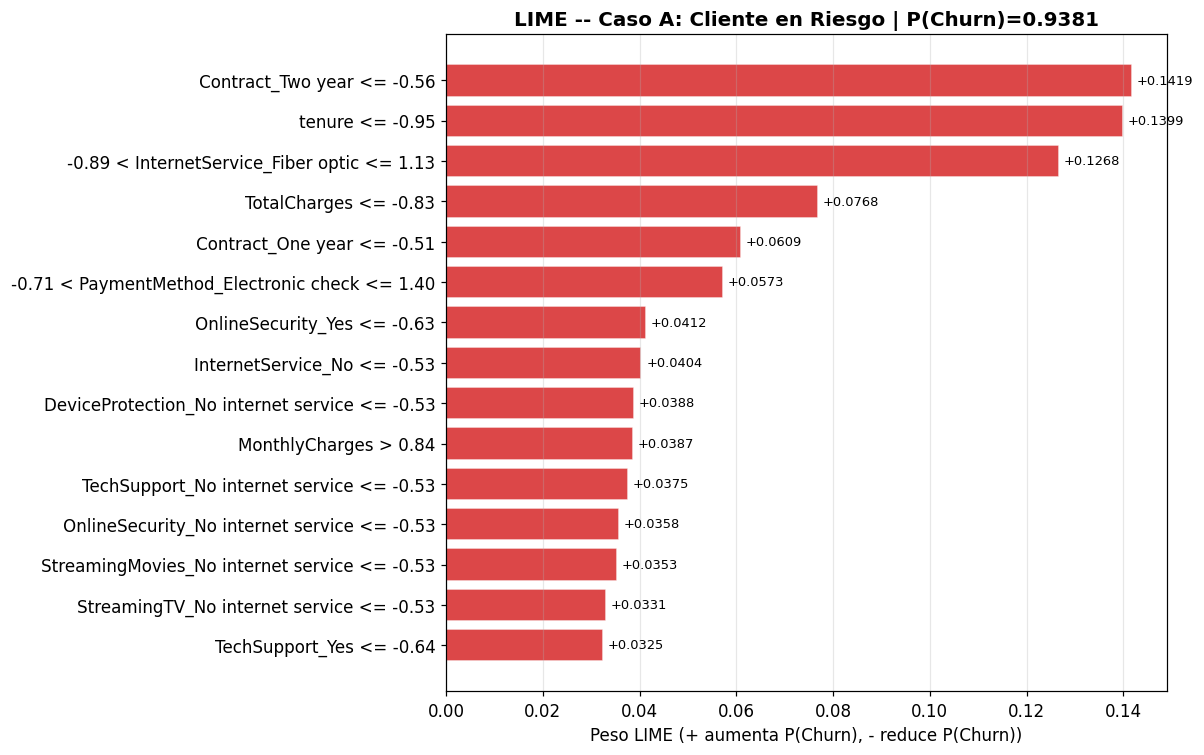

In [46]:
lime_list_a   = exp_lime_a.as_list(label=1)
lime_names_a  = [x[0] for x in lime_list_a]
lime_weights_a = [x[1] for x in lime_list_a]

sorted_idx = np.argsort(np.abs(lime_weights_a))
names_sorted   = [lime_names_a[i] for i in sorted_idx]
weights_sorted = [lime_weights_a[i] for i in sorted_idx]
colors_a = ["#d62728" if w > 0 else "#1f77b4" for w in weights_sorted]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(names_sorted, weights_sorted, color=colors_a, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Peso LIME (+ aumenta P(Churn), - reduce P(Churn))", fontsize=11)
ax.set_title(f"LIME -- Caso A: Cliente en Riesgo | P(Churn)={prob_lime_a[1]:.4f}",
             fontweight="bold", fontsize=13)
ax.grid(axis="x", alpha=0.3)
for bar, w in zip(bars, weights_sorted):
    ax.text(w + (0.001 if w >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f"{w:+.4f}", va="center", ha="left" if w >= 0 else "right", fontsize=8.5)
plt.tight_layout()
plt.show()


### 5.3 Explicacion LIME -- Caso B: Cliente fiel

In [47]:
instancia_b = X_shap_sample.iloc[caso_b].values

exp_lime_b = explainer_lime.explain_instance(
    data_row   = instancia_b,
    predict_fn = rf.predict_proba,
    num_features = 15,
    num_samples  = 3000,
    labels       = (1,)
)

prob_lime_b = exp_lime_b.predict_proba
print(f"LIME -- Caso B (Cliente Fiel)")
print(f"  P(No Churn) = {prob_lime_b[0]:.4f}")
print(f"  P(Churn)    = {prob_lime_b[1]:.4f}")
print()
print("Top 10 contribuciones LIME:")
for feat, weight in sorted(exp_lime_b.as_list(label=1),
                           key=lambda x: abs(x[1]), reverse=True)[:10]:
    signo = "SUBE" if weight > 0 else "BAJA"
    print(f"  [{signo}] {feat:<50} peso = {weight:+.4f}")


LIME -- Caso B (Cliente Fiel)
  P(No Churn) = 0.9872
  P(Churn)    = 0.0128

Top 10 contribuciones LIME:
  [BAJA] Contract_Two year > -0.56                          peso = -0.1422
  [BAJA] InternetService_Fiber optic <= -0.89               peso = -0.1255
  [BAJA] tenure > 0.96                                      peso = -0.1122
  [BAJA] PaymentMethod_Electronic check <= -0.71            peso = -0.0619
  [SUBE] Contract_One year <= -0.51                         peso = +0.0592
  [BAJA] InternetService_No > -0.53                         peso = -0.0413
  [BAJA] DeviceProtection_No internet service > -0.53       peso = -0.0412
  [SUBE] OnlineSecurity_Yes <= -0.63                        peso = +0.0411
  [BAJA] -0.39 < TotalCharges <= 0.67                       peso = -0.0403
  [BAJA] OnlineSecurity_No internet service > -0.53         peso = -0.0369


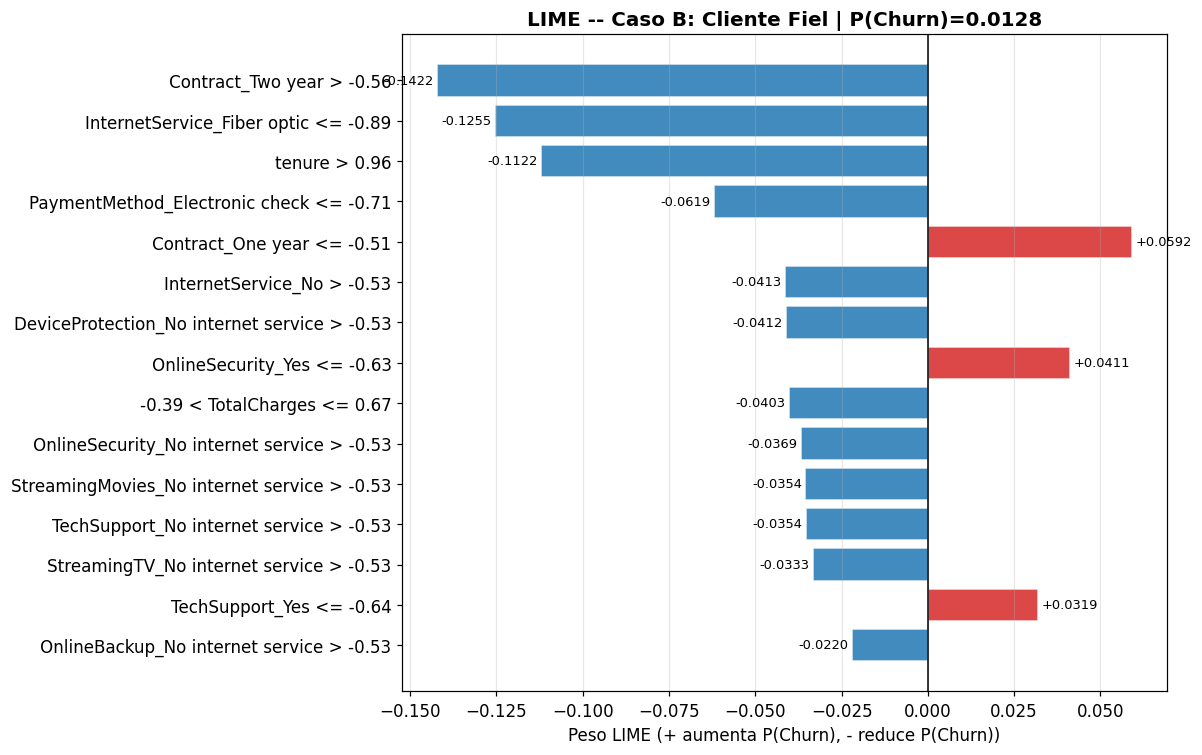

In [48]:
lime_list_b    = exp_lime_b.as_list(label=1)
lime_names_b   = [x[0] for x in lime_list_b]
lime_weights_b = [x[1] for x in lime_list_b]

sorted_idx_b   = np.argsort(np.abs(lime_weights_b))
names_s_b      = [lime_names_b[i] for i in sorted_idx_b]
weights_s_b    = [lime_weights_b[i] for i in sorted_idx_b]
colors_b       = ["#d62728" if w > 0 else "#1f77b4" for w in weights_s_b]

fig, ax = plt.subplots(figsize=(11, 7))
bars_b = ax.barh(names_s_b, weights_s_b, color=colors_b, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Peso LIME (+ aumenta P(Churn), - reduce P(Churn))", fontsize=11)
ax.set_title(f"LIME -- Caso B: Cliente Fiel | P(Churn)={prob_lime_b[1]:.4f}",
             fontweight="bold", fontsize=13)
ax.grid(axis="x", alpha=0.3)
for bar, w in zip(bars_b, weights_s_b):
    ax.text(w + (0.001 if w >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f"{w:+.4f}", va="center", ha="left" if w >= 0 else "right", fontsize=8.5)
plt.tight_layout()
plt.show()


### 5.4 Comparacion SHAP vs LIME | mismos casos

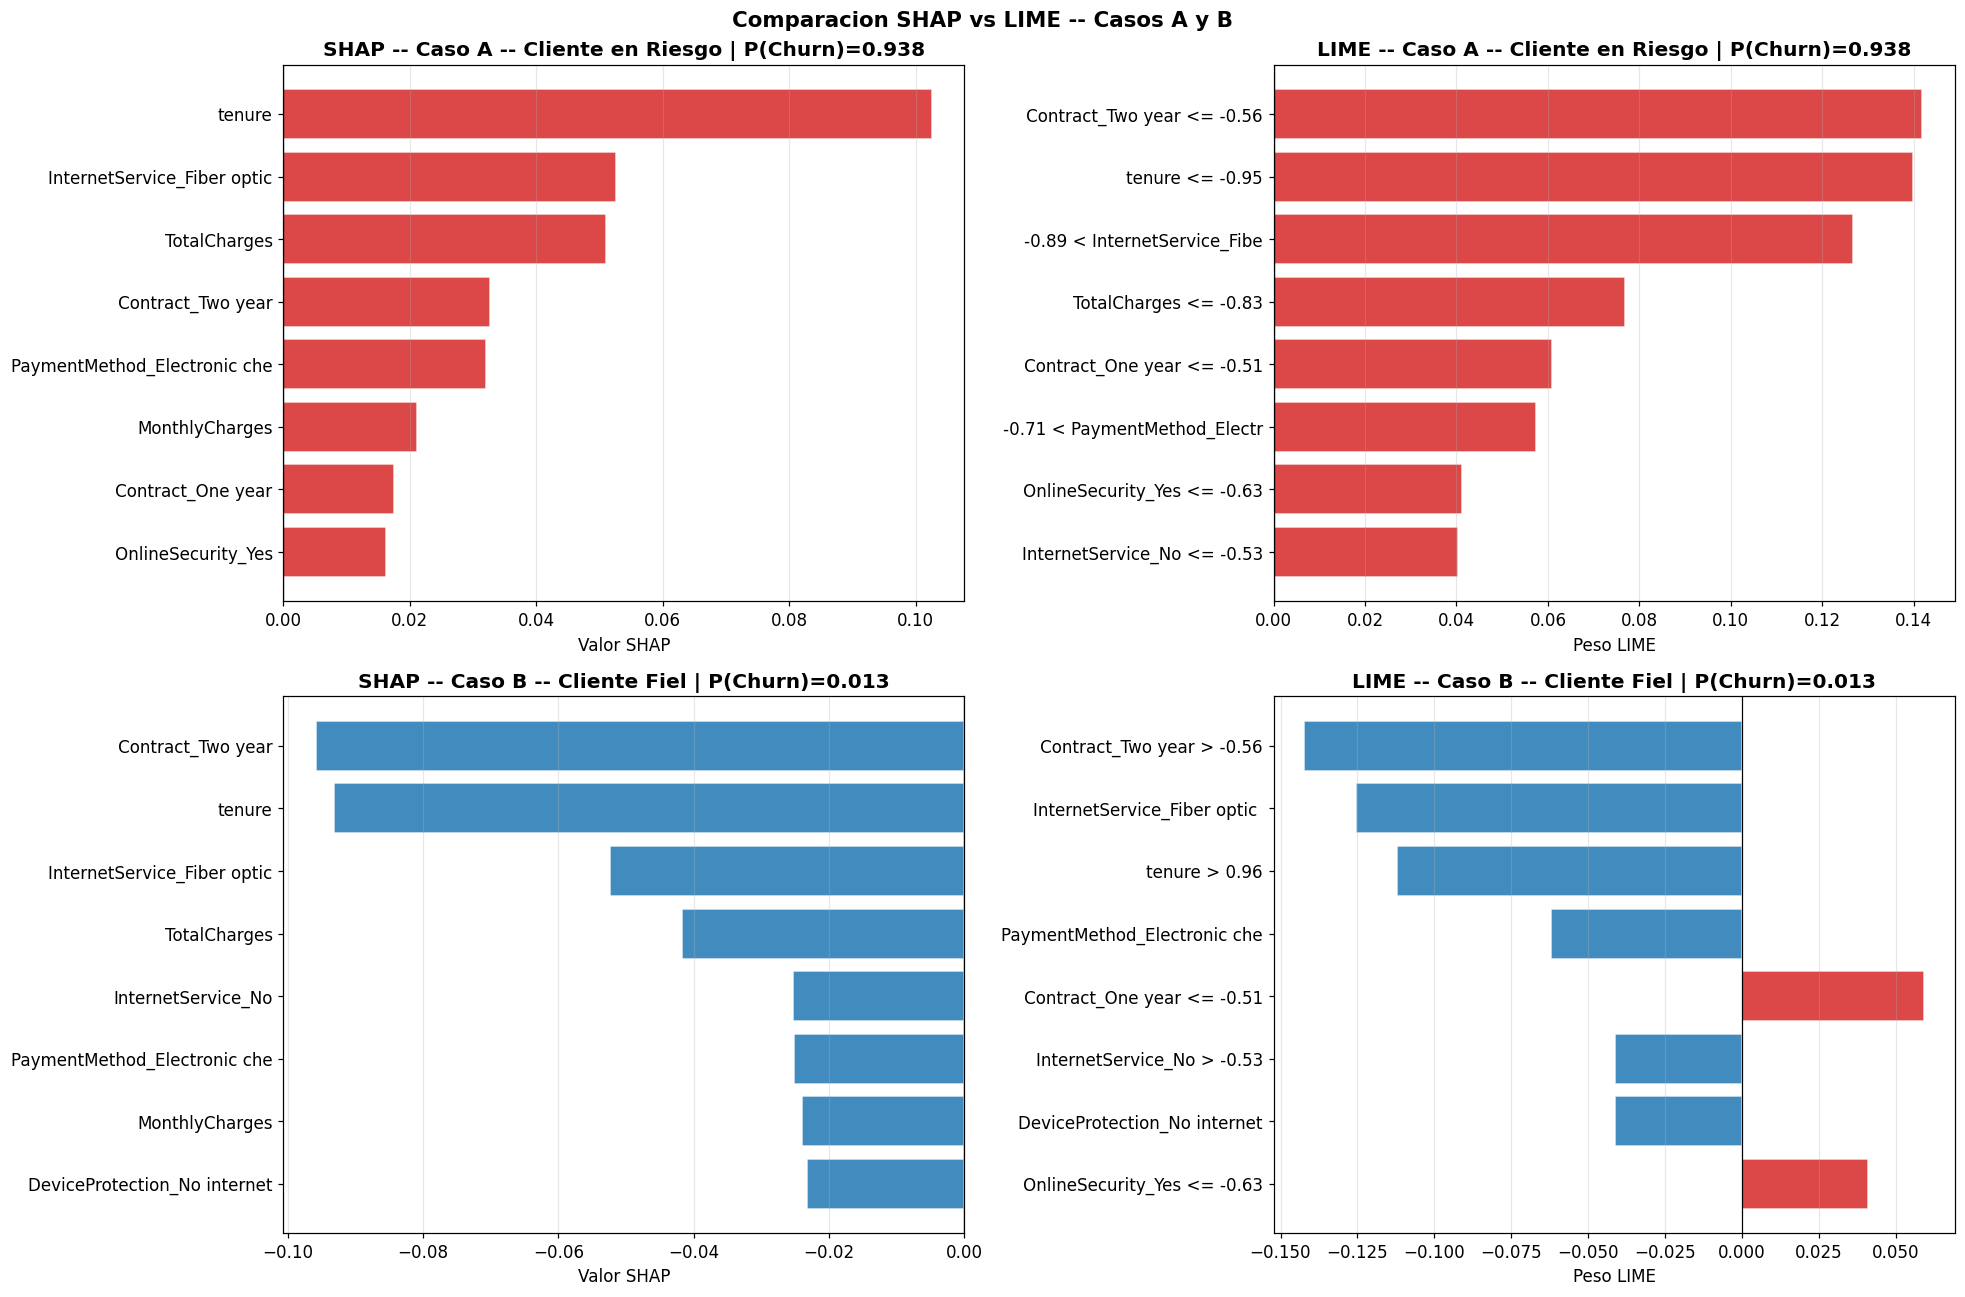

Observaciones SHAP vs LIME:
  - Ambos identifican las mismas variables clave (coherencia)
  - SHAP: escala directa de probabilidad, suma = prediccion - base
  - LIME: aproximacion lineal local, puede diferir ligeramente en magnitudes
  - Barras rojas: factores de riesgo de Churn
  - Barras azules: factores protectores contra el Churn


In [49]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Comparacion SHAP vs LIME -- Casos A y B",
             fontweight="bold", fontsize=14)

configs = [
    (caso_a, "A -- Cliente en Riesgo", lime_list_a, prob_lime_a[1], 0),
    (caso_b, "B -- Cliente Fiel",      lime_list_b, prob_lime_b[1], 1),
]

for row, (caso, titulo, lime_list, prob_lime, row_idx) in enumerate(configs):
    # SHAP
    shap_vals = shap_churn[caso]
    top8_shap = np.argsort(np.abs(shap_vals))[-8:]
    shap_names_p  = [feature_names[i][:28] for i in top8_shap]
    shap_vals_p   = [shap_vals[i] for i in top8_shap]
    colors_shap   = ["#d62728" if v > 0 else "#1f77b4" for v in shap_vals_p]

    axes[row, 0].barh(shap_names_p, shap_vals_p, color=colors_shap,
                      edgecolor="white", alpha=0.85)
    axes[row, 0].axvline(0, color="black", linewidth=0.8)
    axes[row, 0].set_title(f"SHAP -- Caso {titulo} | P(Churn)={y_prob_shap[caso]:.3f}",
                            fontweight="bold")
    axes[row, 0].set_xlabel("Valor SHAP")
    axes[row, 0].grid(axis="x", alpha=0.3)

    # LIME
    lime_sorted = sorted(lime_list, key=lambda x: abs(x[1]), reverse=True)[:8]
    lime_n      = [x[0][:28] for x in lime_sorted][::-1]
    lime_w      = [x[1] for x in lime_sorted][::-1]
    colors_lime = ["#d62728" if v > 0 else "#1f77b4" for v in lime_w]

    axes[row, 1].barh(lime_n, lime_w, color=colors_lime, edgecolor="white", alpha=0.85)
    axes[row, 1].axvline(0, color="black", linewidth=0.8)
    axes[row, 1].set_title(f"LIME -- Caso {titulo} | P(Churn)={prob_lime:.3f}",
                            fontweight="bold")
    axes[row, 1].set_xlabel("Peso LIME")
    axes[row, 1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Observaciones SHAP vs LIME:")
print("  - Ambos identifican las mismas variables clave (coherencia)")
print("  - SHAP: escala directa de probabilidad, suma = prediccion - base")
print("  - LIME: aproximacion lineal local, puede diferir ligeramente en magnitudes")
print("  - Barras rojas: factores de riesgo de Churn")
print("  - Barras azules: factores protectores contra el Churn")


---
# 6. Visualizaciones comparativas, resultados guardados y reflexion

> **Importante:** Todo el codigo anterior se conserva tal como estaba en el notebook original.  
> A partir de esta seccion se agregan unicamente los puntos adicionales solicitados para completar los apartados 4, 5, 6 y 7 de la actividad.

## 6.1 Punto 4 y 5: Visualizaciones adicionales solicitadas

En esta seccion se agregan graficos para mostrar:

- Variables que mas influyen en la decision del modelo.
- Comparacion de explicaciones entre diferentes tecnicas: **SHAP**, **importancia interna de Random Forest**, **Permutation Importance** y **LIME**.
- Explicaciones individuales de predicciones concretas para 2 clientes: un caso con alto riesgo de churn y otro caso con bajo riesgo.

Ademas, los resultados se guardan en carpetas del repositorio para cumplir con el requisito de entregar metricas y visualizaciones.

In [50]:
# ============================================================
# Configuracion de carpetas para guardar resultados del repo
# ============================================================
from pathlib import Path
import json
from sklearn.inspection import permutation_importance

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Funcion auxiliar para guardar figuras con formato uniforme
def guardar_figura(nombre_archivo):
    ruta = FIGURES_DIR / nombre_archivo
    plt.tight_layout()
    plt.savefig(ruta, dpi=160, bbox_inches="tight")
    print(f"Figura guardada: {ruta}")
    plt.show()

metricas_modelo = {
    "accuracy_random_forest": float(accuracy_score(y_test, y_pred_rf)),
    "recall_random_forest": float(recall_score(y_test, y_pred_rf)),
    "f1_random_forest": float(f1_score(y_test, y_pred_rf)),
    "auc_roc_random_forest": float(roc_auc_score(y_test, y_prob_rf)),
    "auc_roc_logistic_regression": float(roc_auc_score(y_test, y_prob_lr)),
    "cantidad_variables": int(len(feature_names)),
    "filas_dataset_procesado": int(len(df_encoded)),
    "filas_train": int(len(X_train)),
    "filas_test": int(len(X_test))
}

with open(METRICS_DIR / "metricas_modelo.json", "w", encoding="utf-8") as f:
    json.dump(metricas_modelo, f, indent=4, ensure_ascii=False)

pd.DataFrame([metricas_modelo]).to_csv(METRICS_DIR / "metricas_modelo.csv", index=False)
metricas_modelo

metricas_modelo.json y metricas_modelo.csv guardados en results/metrics/


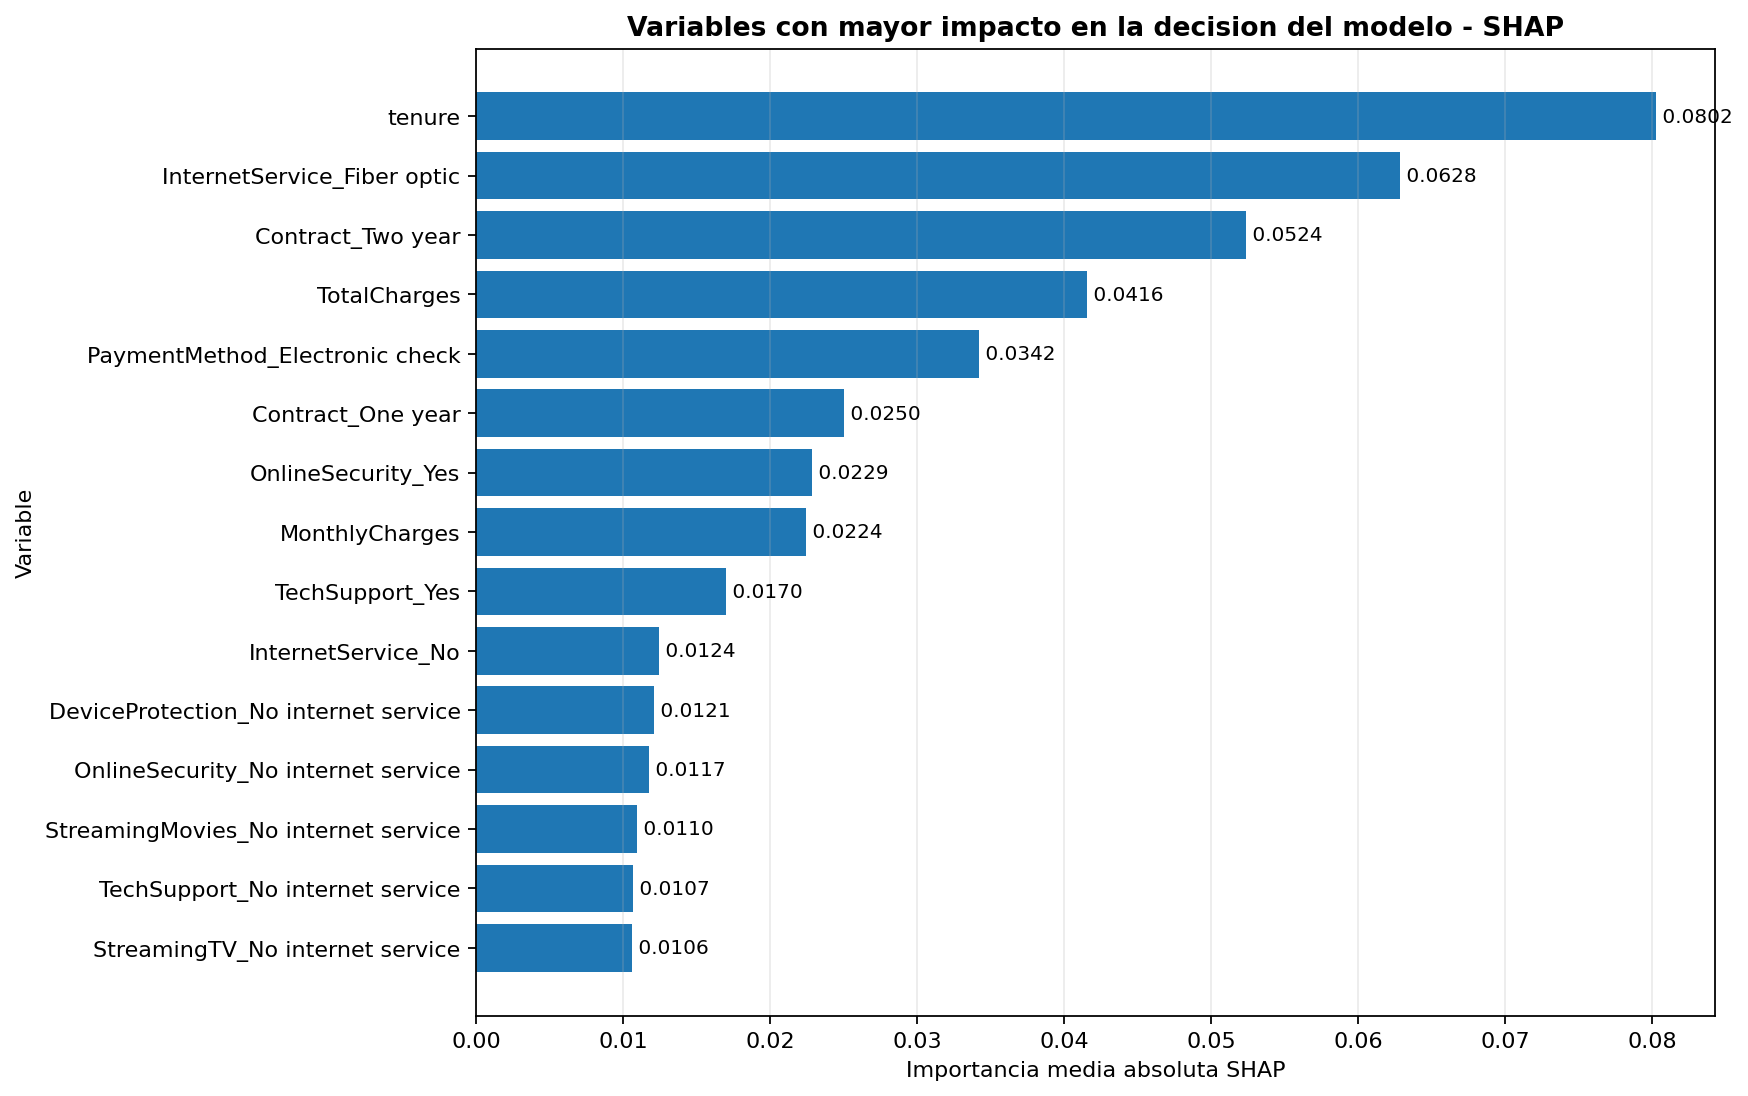

Top 10 variables segun SHAP:


variable,importancia_shap_media_abs
tenure,0.080241
InternetService_Fiber optic,0.062828
Contract_Two year,0.052393
TotalCharges,0.041564
PaymentMethod_Electronic check,0.034179
Contract_One year,0.025022
OnlineSecurity_Yes,0.022880
MonthlyCharges,0.022418
TechSupport_Yes,0.017031
InternetService_No,0.012433


In [51]:
# ============================================================
# Visualizacion 1: Variables con mayor impacto segun SHAP
# ============================================================
shap_global_df = (
    pd.DataFrame({
        "variable": feature_names,
        "importancia_shap_media_abs": np.abs(shap_churn).mean(axis=0)
    })
    .sort_values("importancia_shap_media_abs", ascending=False)
)

shap_global_df.to_csv(METRICS_DIR / "importancia_global_shap.csv", index=False)

top_shap = shap_global_df.head(15).sort_values("importancia_shap_media_abs")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_shap["variable"], top_shap["importancia_shap_media_abs"])
ax.set_title("Variables con mayor impacto en la decision del modelo - SHAP", fontweight="bold")
ax.set_xlabel("Importancia media absoluta SHAP")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.25)
for i, v in enumerate(top_shap["importancia_shap_media_abs"]):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=9)
guardar_figura("01_variables_mayor_impacto_shap.png")

print("Top 10 variables segun SHAP:")
display(shap_global_df.head(10))

Calculando Permutation Importance...


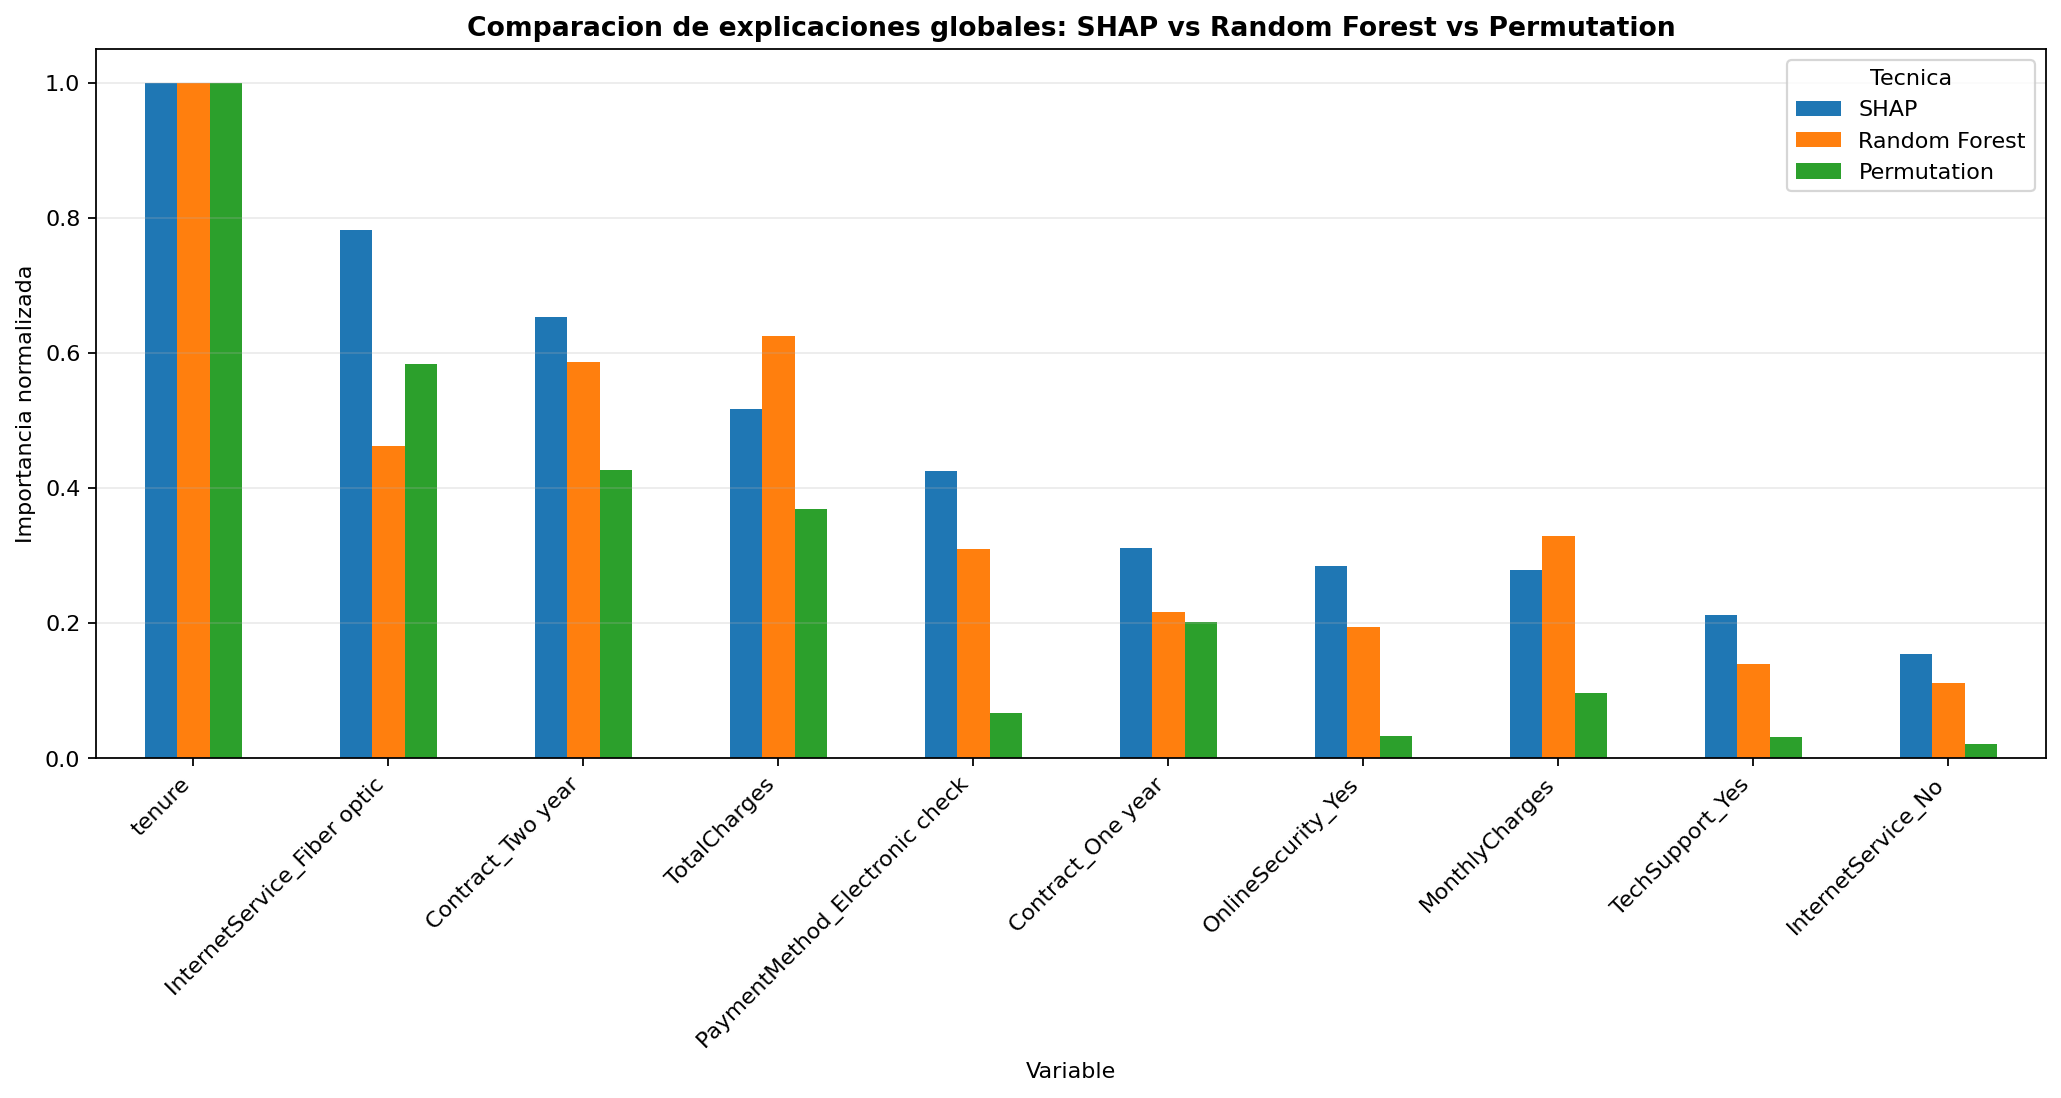

importancia_shap_media_abs,importancia_rf,importancia_permutation
0.080241,0.197433,0.044924
0.062828,0.091405,0.026252
0.052393,0.115754,0.019162
0.041564,0.123411,0.016617
0.034179,0.061067,0.003029
0.025022,0.042729,0.009098
0.022880,0.038539,0.001461
0.022418,0.065077,0.004374
0.017031,0.027690,0.001444
0.012433,0.022061,0.000939


In [52]:
# ============================================================
# Visualizacion 2: Comparacion de tecnicas globales
# SHAP vs importancia interna Random Forest vs Permutation Importance
# ============================================================
rf_importance_df = pd.DataFrame({
    "variable": feature_names,
    "importancia_rf": rf.feature_importances_
}).sort_values("importancia_rf", ascending=False)

print("Calculando Permutation Importance...")
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1
)

perm_importance_df = pd.DataFrame({
    "variable": feature_names,
    "importancia_permutation": perm.importances_mean
}).sort_values("importancia_permutation", ascending=False)

comparacion_global = (
    shap_global_df.merge(rf_importance_df, on="variable")
                  .merge(perm_importance_df, on="variable")
)

for col in ["importancia_shap_media_abs", "importancia_rf", "importancia_permutation"]:
    max_val = comparacion_global[col].max()
    comparacion_global[col + "_norm"] = comparacion_global[col] / max_val if max_val != 0 else 0

comparacion_global.to_csv(METRICS_DIR / "comparacion_tecnicas_globales.csv", index=False)

top_vars_comparacion = shap_global_df.head(10)["variable"].tolist()
plot_df = comparacion_global[comparacion_global["variable"].isin(top_vars_comparacion)].copy()
plot_df = plot_df.set_index("variable").loc[top_vars_comparacion]

fig, ax = plt.subplots(figsize=(13, 7))
plot_df[[
    "importancia_shap_media_abs_norm",
    "importancia_rf_norm",
    "importancia_permutation_norm"
]].plot(kind="bar", ax=ax)
ax.set_title("Comparacion de explicaciones globales: SHAP vs Random Forest vs Permutation", fontweight="bold")
ax.set_ylabel("Importancia normalizada")
ax.set_xlabel("Variable")
ax.legend(["SHAP", "Random Forest", "Permutation"], title="Tecnica")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45, ha="right")
guardar_figura("02_comparacion_tecnicas_globales.png")

display(plot_df[[
    "importancia_shap_media_abs", "importancia_rf", "importancia_permutation"
]])

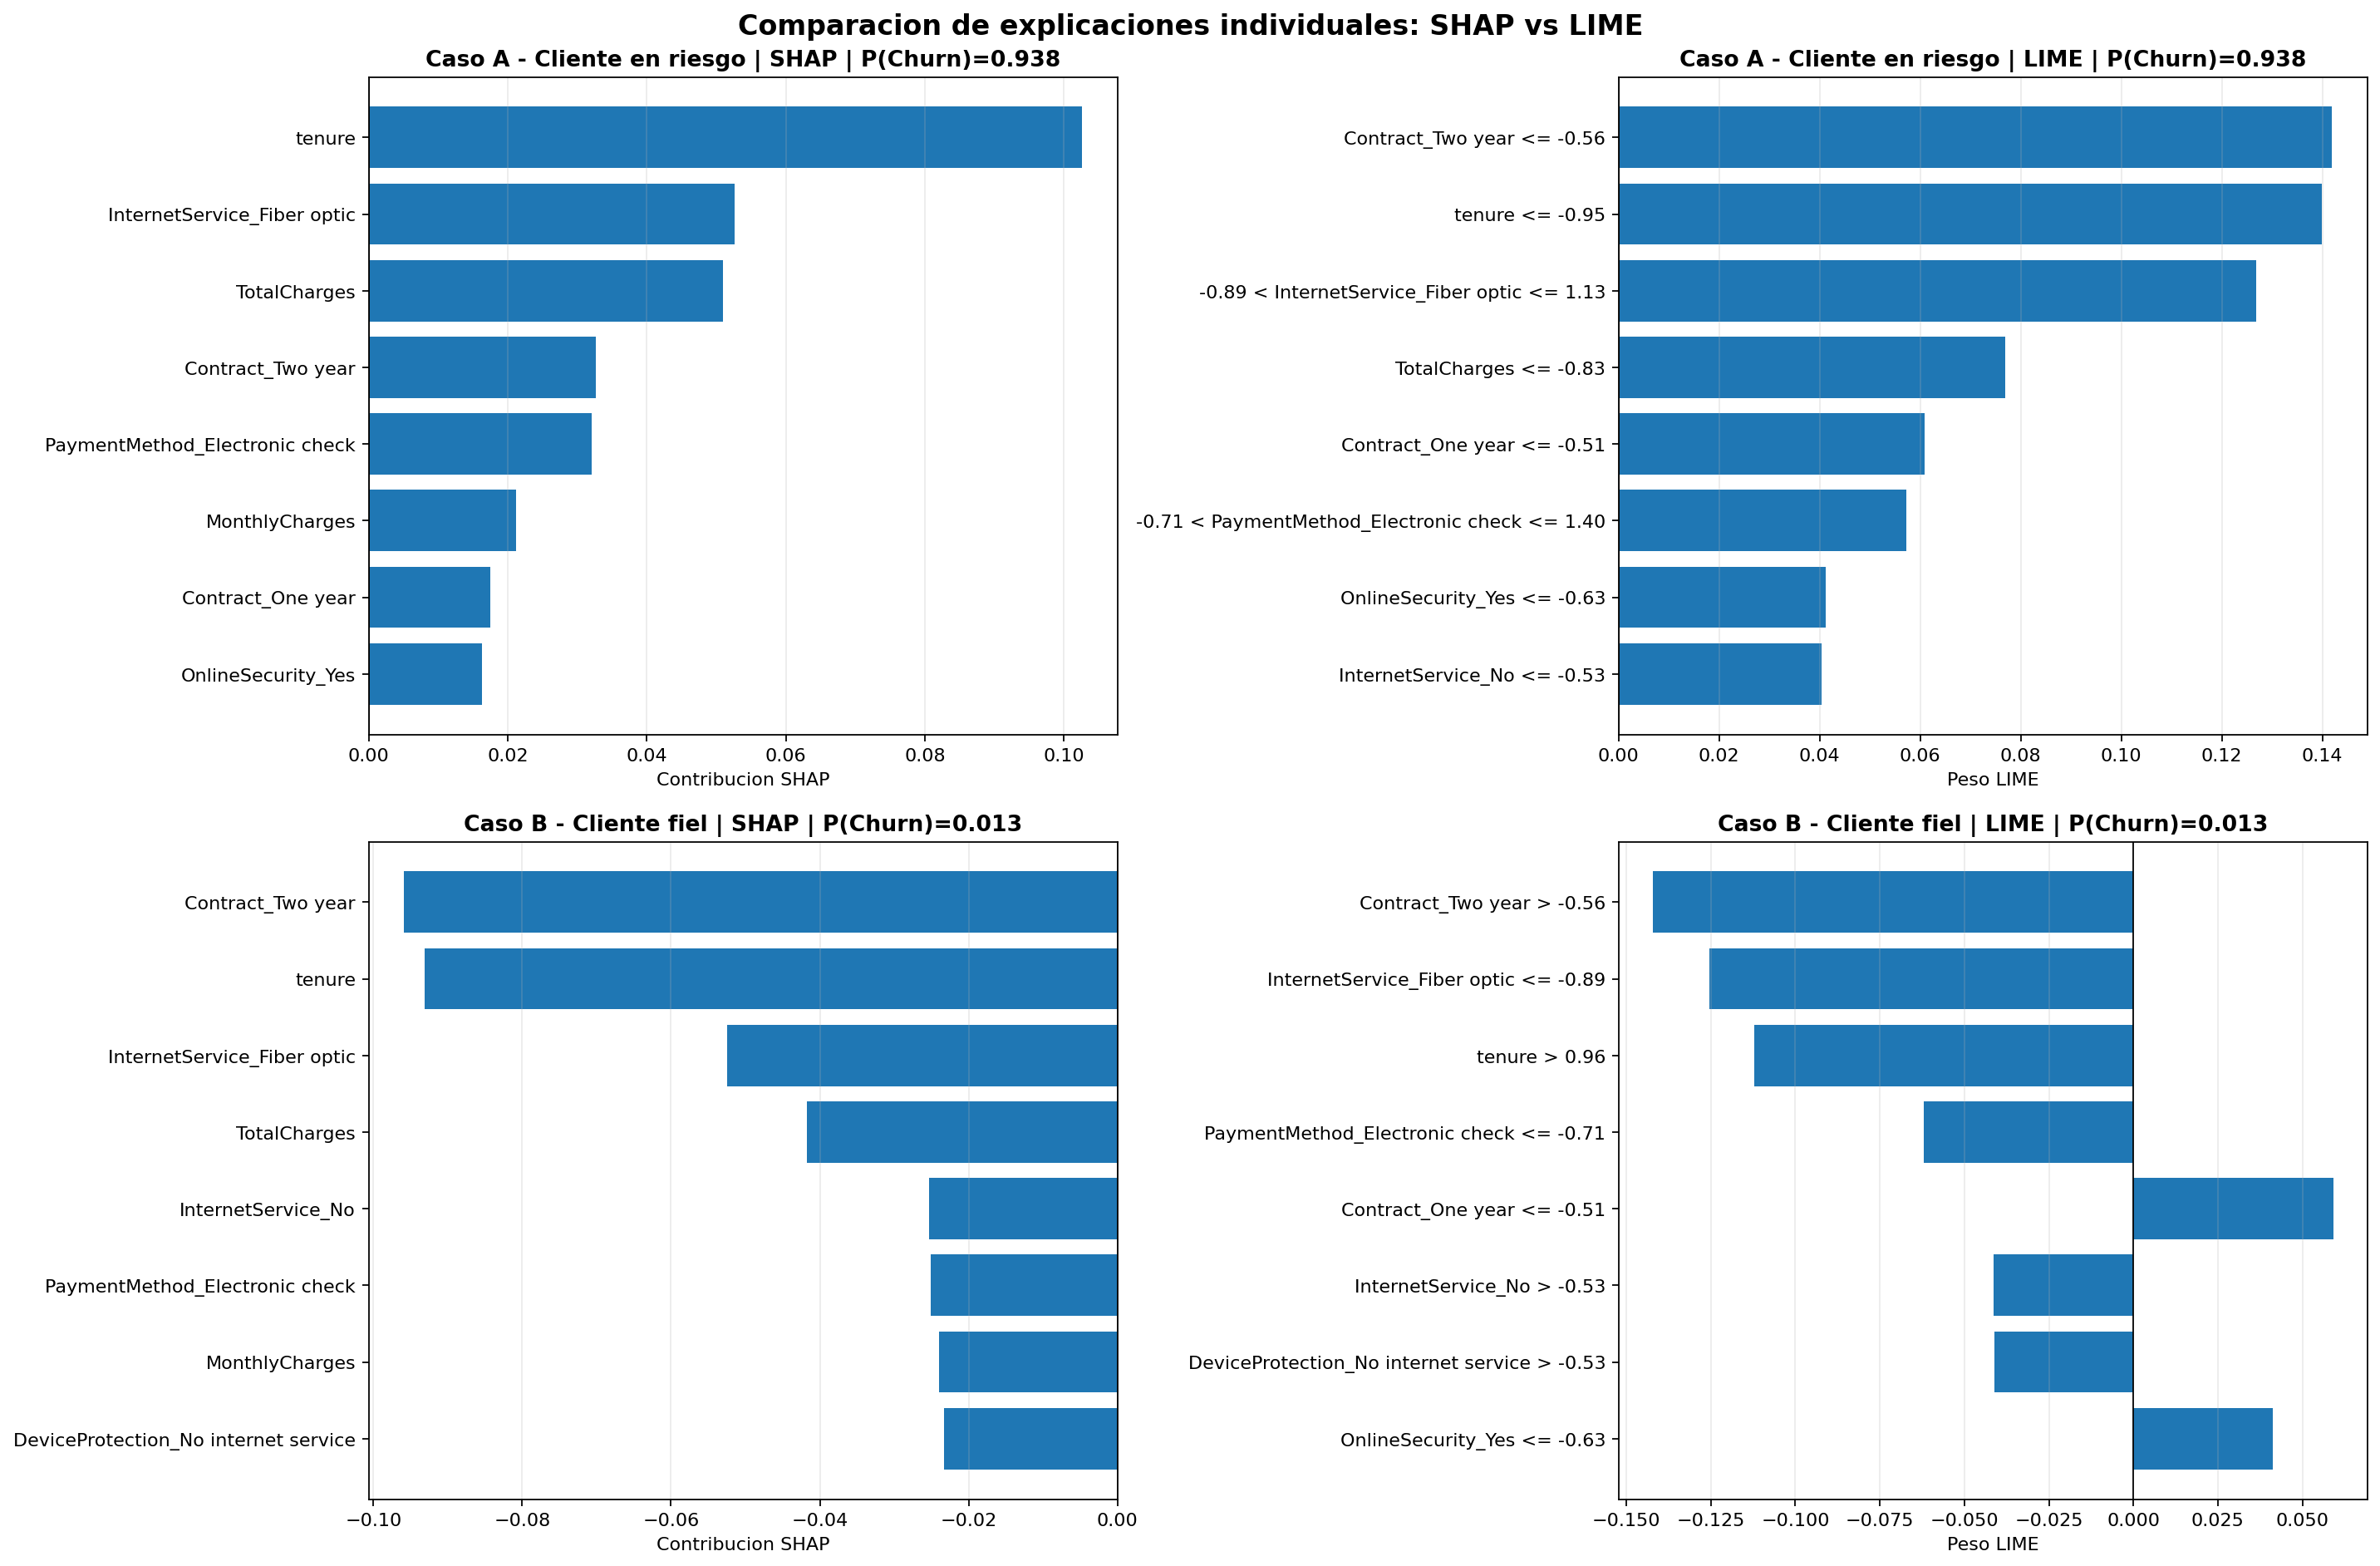

In [53]:
# ============================================================
# Visualizacion 3: Comparacion SHAP vs LIME en casos individuales
# Se reutilizan los casos A y B calculados en el notebook original.
# ============================================================
def obtener_top_shap_caso(caso, n=8):
    valores = shap_churn[caso]
    idx = np.argsort(np.abs(valores))[-n:][::-1]
    return pd.DataFrame({
        "variable": [feature_names[i] for i in idx],
        "contribucion_shap": [valores[i] for i in idx]
    })

def obtener_top_lime(lime_list, n=8):
    return pd.DataFrame(lime_list, columns=["variable_lime", "contribucion_lime"]).assign(
        abs_lime=lambda d: d["contribucion_lime"].abs()
    ).sort_values("abs_lime", ascending=False).head(n).drop(columns="abs_lime")

shap_caso_a_df = obtener_top_shap_caso(caso_a, 8)
shap_caso_b_df = obtener_top_shap_caso(caso_b, 8)
lime_caso_a_df = obtener_top_lime(lime_list_a, 8)
lime_caso_b_df = obtener_top_lime(lime_list_b, 8)

shap_caso_a_df.to_csv(METRICS_DIR / "caso_a_top_shap.csv", index=False)
shap_caso_b_df.to_csv(METRICS_DIR / "caso_b_top_shap.csv", index=False)
lime_caso_a_df.to_csv(METRICS_DIR / "caso_a_top_lime.csv", index=False)
lime_caso_b_df.to_csv(METRICS_DIR / "caso_b_top_lime.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Comparacion de explicaciones individuales: SHAP vs LIME", fontweight="bold", fontsize=15)

axes[0, 0].barh(shap_caso_a_df["variable"][::-1], shap_caso_a_df["contribucion_shap"][::-1])
axes[0, 0].axvline(0, color="black", linewidth=0.8)
axes[0, 0].set_title(f"Caso A - Cliente en riesgo | SHAP | P(Churn)={y_prob_shap[caso_a]:.3f}", fontweight="bold")
axes[0, 0].set_xlabel("Contribucion SHAP")
axes[0, 0].grid(axis="x", alpha=0.25)

axes[0, 1].barh(lime_caso_a_df["variable_lime"][::-1], lime_caso_a_df["contribucion_lime"][::-1])
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].set_title(f"Caso A - Cliente en riesgo | LIME | P(Churn)={prob_lime_a[1]:.3f}", fontweight="bold")
axes[0, 1].set_xlabel("Peso LIME")
axes[0, 1].grid(axis="x", alpha=0.25)

axes[1, 0].barh(shap_caso_b_df["variable"][::-1], shap_caso_b_df["contribucion_shap"][::-1])
axes[1, 0].axvline(0, color="black", linewidth=0.8)
axes[1, 0].set_title(f"Caso B - Cliente fiel | SHAP | P(Churn)={y_prob_shap[caso_b]:.3f}", fontweight="bold")
axes[1, 0].set_xlabel("Contribucion SHAP")
axes[1, 0].grid(axis="x", alpha=0.25)

axes[1, 1].barh(lime_caso_b_df["variable_lime"][::-1], lime_caso_b_df["contribucion_lime"][::-1])
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_title(f"Caso B - Cliente fiel | LIME | P(Churn)={prob_lime_b[1]:.3f}", fontweight="bold")
axes[1, 1].set_xlabel("Peso LIME")
axes[1, 1].grid(axis="x", alpha=0.25)

guardar_figura("03_comparacion_shap_lime_casos_individuales.png")

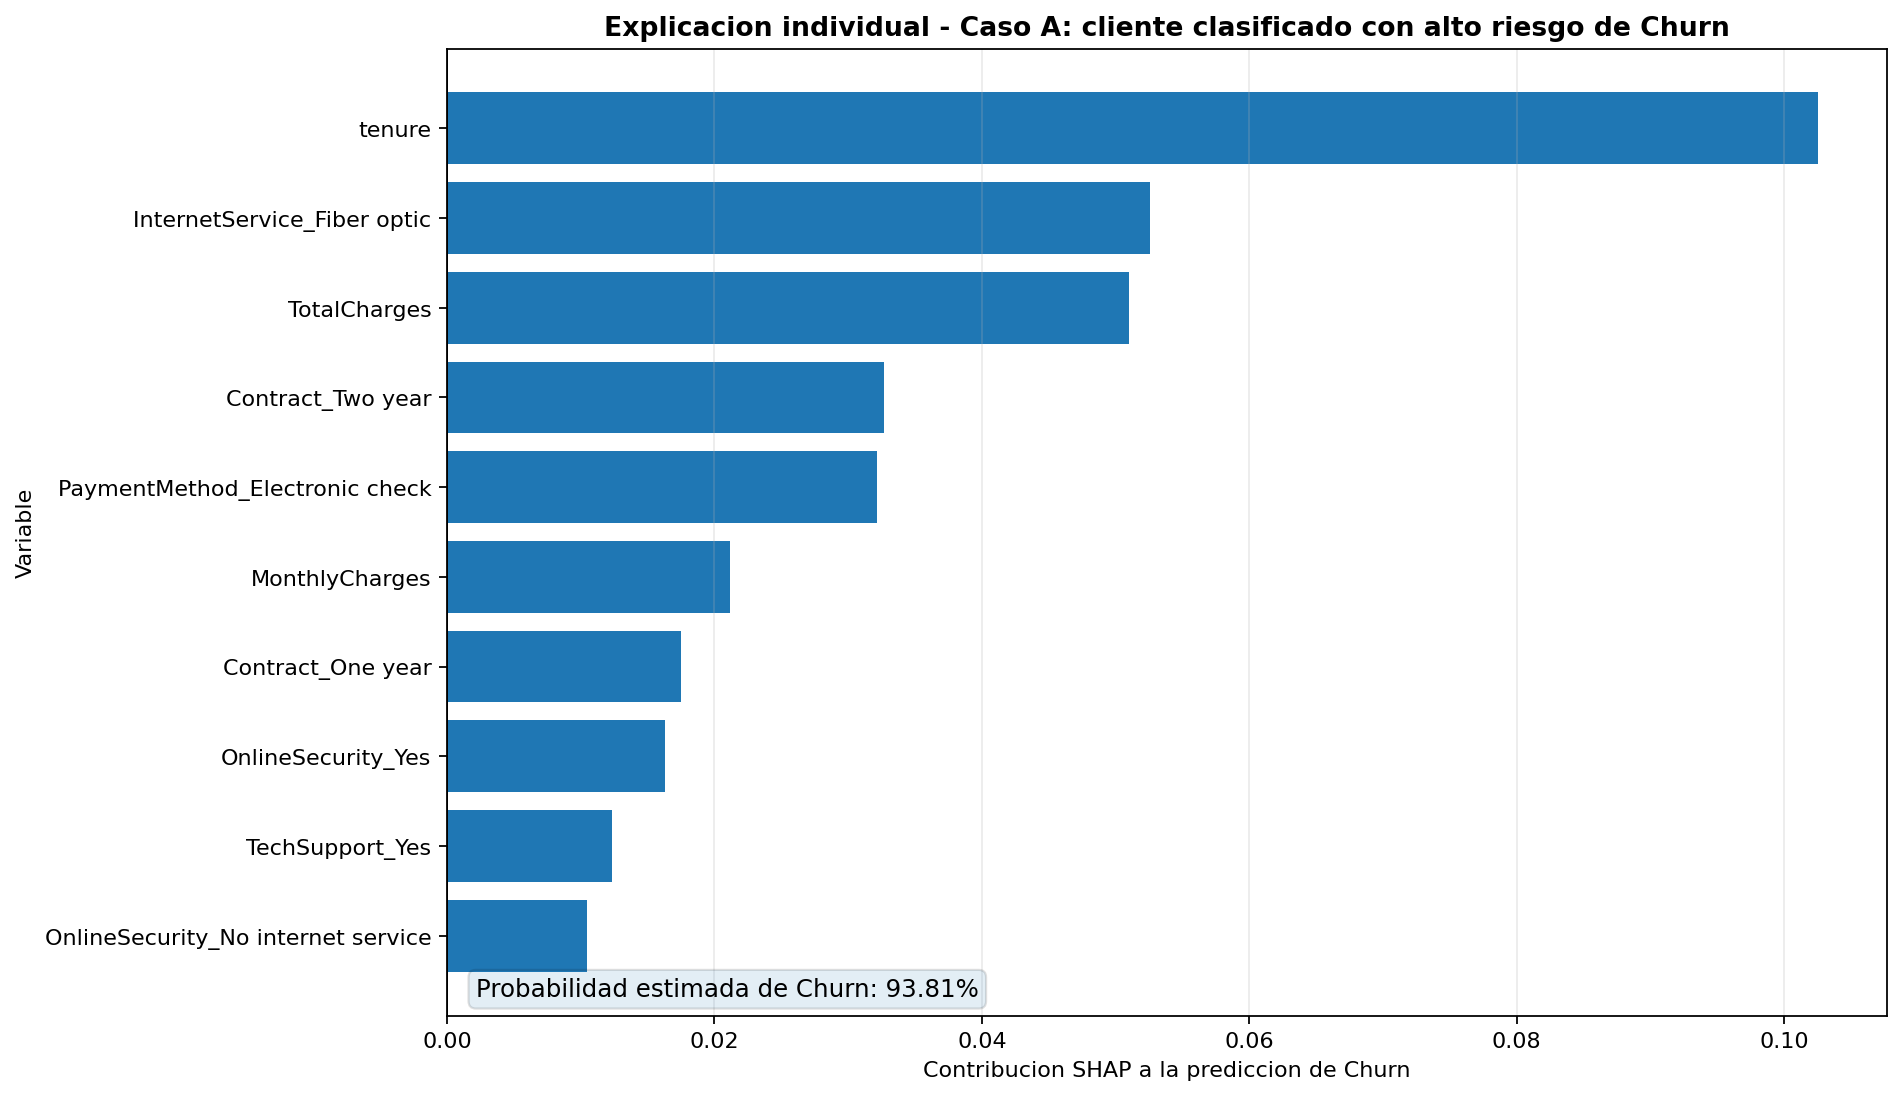

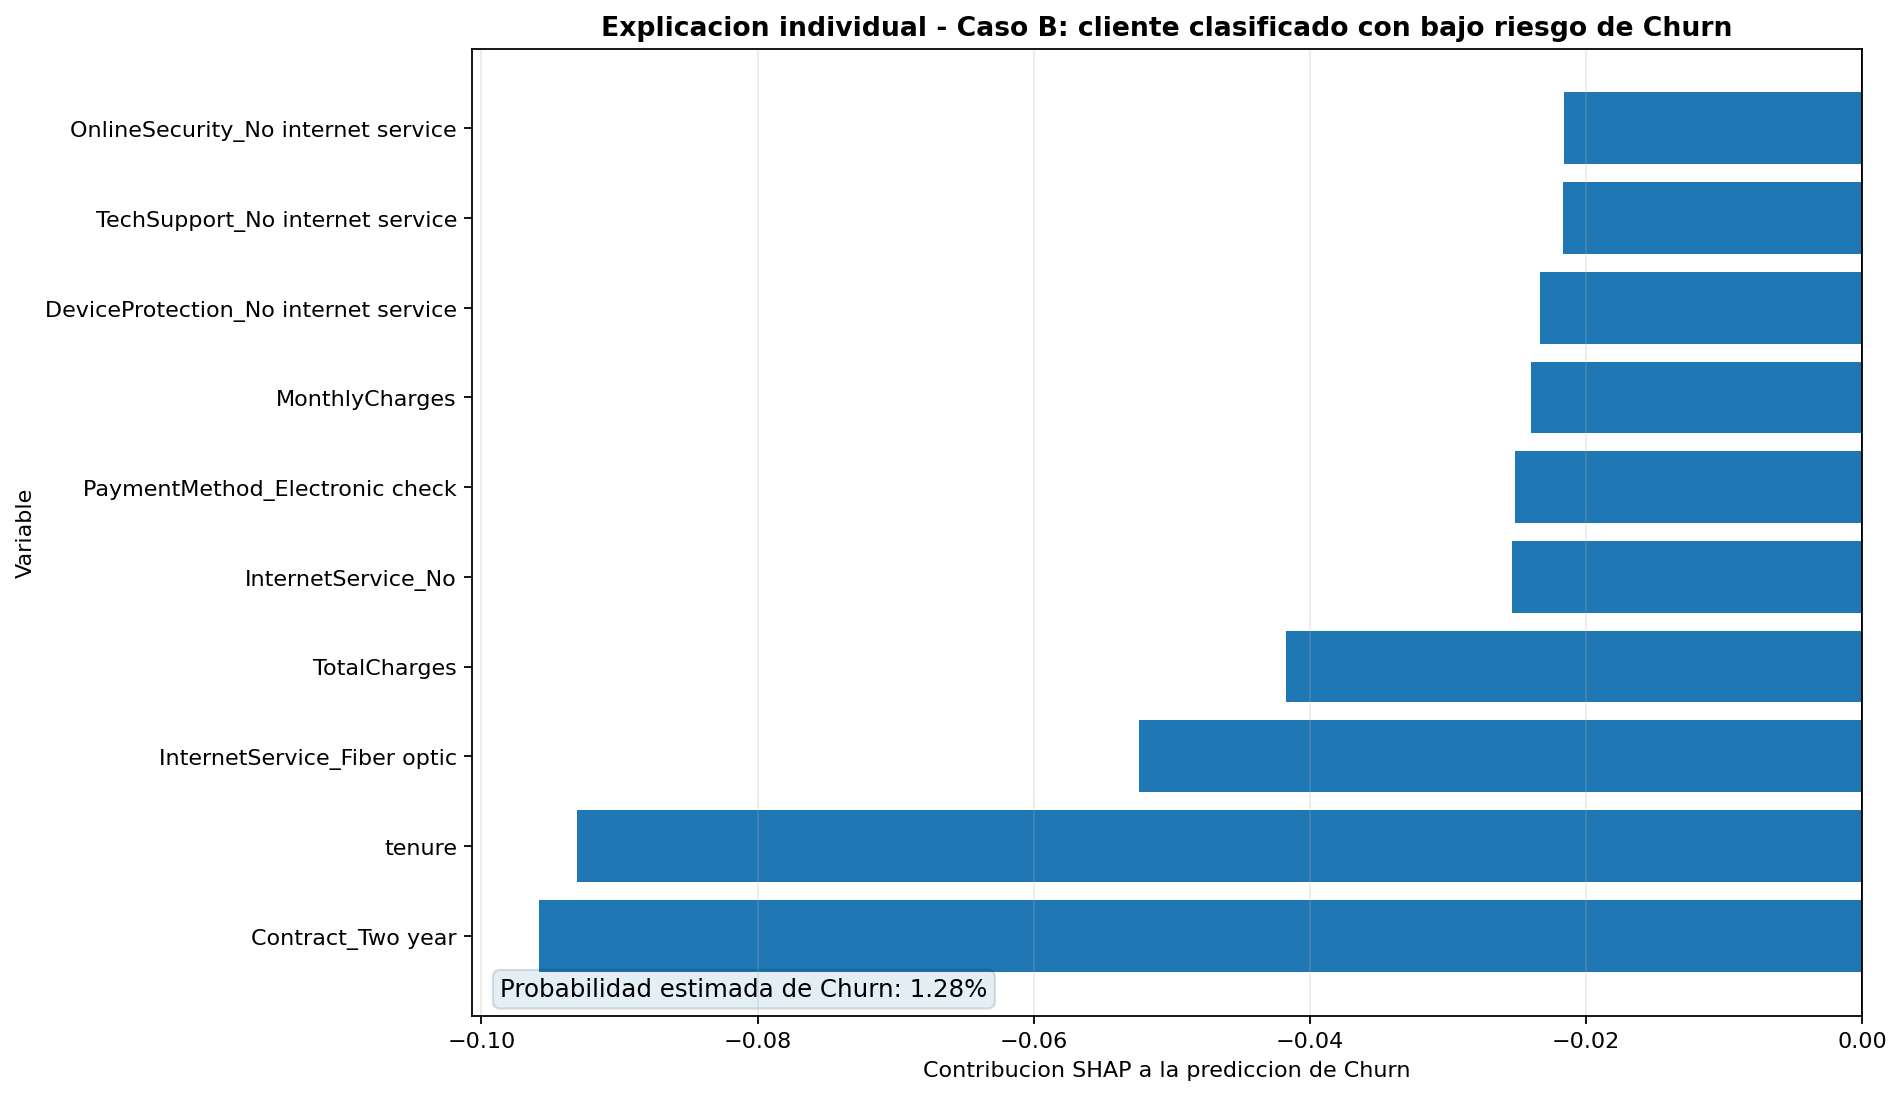

In [54]:
# ============================================================
# Visualizacion 4: Casos individuales con decision explicada
# Grafico resumido de factores que suben o bajan la probabilidad de churn.
# ============================================================
def graficar_decision_individual(caso, titulo, nombre_archivo):
    shap_df = obtener_top_shap_caso(caso, 10).sort_values("contribucion_shap")
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(shap_df["variable"], shap_df["contribucion_shap"])
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Contribucion SHAP a la prediccion de Churn")
    ax.set_ylabel("Variable")
    ax.grid(axis="x", alpha=0.25)
    prob = rf.predict_proba(X_shap_sample.iloc[[caso]])[0, 1]
    ax.text(0.02, 0.02, f"Probabilidad estimada de Churn: {prob:.2%}", transform=ax.transAxes,
            fontsize=11, bbox=dict(boxstyle="round", alpha=0.12))
    guardar_figura(nombre_archivo)

graficar_decision_individual(
    caso_a,
    "Explicacion individual - Caso A: cliente clasificado con alto riesgo de Churn",
    "04_caso_a_decision_explicada.png"
)

graficar_decision_individual(
    caso_b,
    "Explicacion individual - Caso B: cliente clasificado con bajo riesgo de Churn",
    "05_caso_b_decision_explicada.png"
)

## 6.2 Analisis interpretativo y reflexivo

### Transparencia del modelo

El modelo Random Forest logra un buen rendimiento predictivo para identificar clientes con probabilidad de cancelar el servicio; sin embargo, por su naturaleza de ensamble, no es completamente interpretable de forma directa. Por esa razon, el uso de tecnicas de explicabilidad como SHAP y LIME es fundamental. SHAP permite analizar el comportamiento global del modelo y conocer que variables influyen mas en la prediccion general. LIME, por otro lado, permite explicar decisiones individuales mediante una aproximacion local.

La transparencia mejora porque no solo se obtiene una etiqueta final, como `Churn` o `No Churn`, sino tambien una justificacion basada en variables concretas. Por ejemplo, variables como el tipo de contrato, la permanencia del cliente, el cargo total y el metodo de pago ayudan a entender por que el modelo aumenta o reduce la probabilidad de abandono.

### Riesgos eticos y sociales si se implementa el sistema

Si este sistema se implementa sin controles, podria generar decisiones injustas o poco claras. Por ejemplo, la empresa podria priorizar beneficios, descuentos o llamadas de retencion solo para ciertos perfiles de clientes, dejando fuera a otros usuarios que tambien necesitan atencion. Tambien existe el riesgo de usar variables que funcionen como indicadores indirectos de condiciones sociales o economicas, generando sesgos en la gestion comercial.

Otro riesgo es que el modelo sea tratado como una verdad absoluta. Si una prediccion incorrecta clasifica a un cliente como de bajo riesgo, la empresa podria no atenderlo a tiempo. De igual forma, si clasifica a un cliente como de alto riesgo sin una explicacion adecuada, podria recibir acciones comerciales innecesarias o invasivas.

### Consideraciones para mejorar el modelo

Para mejorar el sistema, se recomienda evaluar periodicamente el desempeno del modelo con datos recientes, revisar posibles sesgos por grupos de clientes, comparar diferentes algoritmos y ajustar el umbral de decision segun el objetivo del negocio. Tambien seria importante complementar la prediccion con reglas de negocio y validacion humana, especialmente en decisiones sensibles o de impacto comercial directo.

Adicionalmente, se recomienda documentar las variables utilizadas, monitorear cambios en la distribucion de los datos y mantener graficos de explicabilidad actualizados para que el modelo sea auditable.

## 6.3 Reflexion final

### ¿Que aprendizaje se desarrollo sobre como el modelo toma decisiones?

El analisis permite comprender que el modelo no decide de forma aleatoria, sino que identifica patrones historicos asociados al abandono de clientes. Se observa que algunas variables relacionadas con permanencia, tipo de contrato, servicio de internet, cargos y metodo de pago tienen una influencia importante en la prediccion. Esto permite pasar de una vision de “caja negra” a una interpretacion mas clara de los factores que impulsan la decision.

### ¿Hay alguna variable que tenga un peso excesivo?

Segun los graficos de importancia, variables como `tenure`, `Contract_Two year`, `TotalCharges`, `InternetService_Fiber optic` y `PaymentMethod_Electronic check` tienen un peso relevante. Esto no significa necesariamente que sean variables incorrectas, pero si indica que deben monitorearse. Si una variable domina demasiado la prediccion, el modelo podria depender excesivamente de ella y perder capacidad de generalizacion ante nuevos escenarios.

### ¿Que pasaria si este modelo se implementa sin explicabilidad?

Si el modelo se implementa sin explicabilidad, la empresa podria tomar decisiones sin comprender sus causas. Esto reduciria la confianza de usuarios, analistas y responsables del negocio. Tambien dificultaria detectar errores, sesgos o comportamientos injustos. En un contexto real, la explicabilidad es necesaria para justificar acciones, auditar el sistema y asegurar que las decisiones automaticas sean tecnicamente utiles y socialmente responsables.

In [55]:
# ============================================================
# Resumen final automatico para evidenciar cumplimiento
# ============================================================
resumen_cumplimiento = pd.DataFrame({
    "Punto solicitado": [
        "4. Variables que mas influyen en la decision",
        "4. Comparacion de explicaciones entre tecnicas",
        "4. Explicaciones individuales de predicciones concretas",
        "5. Variables con mayor impacto",
        "5. Comparacion de explicaciones",
        "5. Casos individuales con decisiones explicadas",
        "6. Analisis interpretativo y reflexivo",
        "7. Reflexion sobre aprendizaje, variables con peso excesivo y explicabilidad"
    ],
    "Evidencia generada": [
        "Grafico SHAP global y archivo importancia_global_shap.csv",
        "Grafico SHAP vs Random Forest vs Permutation y comparacion SHAP vs LIME",
        "Casos A y B con SHAP y LIME",
        "01_variables_mayor_impacto_shap.png",
        "02_comparacion_tecnicas_globales.png y 03_comparacion_shap_lime_casos_individuales.png",
        "04_caso_a_decision_explicada.png y 05_caso_b_decision_explicada.png",
        "Seccion 6.2 del notebook",
        "Seccion 6.3 del notebook"
    ]
})

resumen_cumplimiento.to_csv(METRICS_DIR / "resumen_cumplimiento.csv", index=False)
display(resumen_cumplimiento)
print("Notebook ampliado manteniendo el codigo original y agregando los puntos solicitados.")

Punto solicitado,Evidencia generada
4. Variables que mas influyen en la decision,Grafico SHAP global y archivo importancia_global_shap.csv
4. Comparacion de explicaciones entre tecnicas,Grafico SHAP vs Random Forest vs Permutation y comparacion SHAP vs LIME
4. Explicaciones individuales de predicciones concretas,Casos A y B con SHAP y LIME
5. Variables con mayor impacto,01_variables_mayor_impacto_shap.png
5. Comparacion de explicaciones,02_comparacion_tecnicas_globales.png y 03_comparacion_shap_lime_casos_individuales.png
5. Casos individuales con decisiones explicadas,04_caso_a_decision_explicada.png y 05_caso_b_decision_explicada.png
6. Analisis interpretativo y reflexivo,Seccion 6.2 del notebook
"7. Reflexion sobre aprendizaje, variables con peso excesivo y explicabilidad",Seccion 6.3 del notebook


Notebook ampliado manteniendo el codigo original y agregando los puntos solicitados.
